# Exploration 1: overview of all omics

Reads the metric files written by `metrics_1_continuous` / `metrics_2_copynumber` and compares the omics,
in-sample (IS) against out-of-sample (OOD). Nothing here writes metric files.

Metric keys used throughout (`m[omic][setting][key]`):
`sharpness` (PIW; entropy for copy number), `calibration` (ENCE; ECE), `scoring` (CRPS; mean log score),
`error` (RMSE; balanced accuracy), `pearson`. Plot helpers are in `omics_plots.py`.
Feature-level deep dives are in `exploration_2_continuous_features`, copy number in `exploration_3_copynumber`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

import omics_config as cfg
import omics_metrics as om
import omics_plots as op

METHOD = "latent"   # which metric files to read: "latent" (latent sampler) | "mcd" (MC Dropout)

m = op.load_metrics(METHOD)              # OOD ENCE > 500 for methylation/crisprcas9 removed (see section 2)
info = op.load_raw_feature_info()        # (variance, % missing, copy-number diversity) of the raw ground truth
tissue = op.load_tissue()

Removed 0 outliers (ENCE > 500) from methylation OOD calibration


Skipped crisprcas9 latent OOD: not evaluated (cfg.UNAVAILABLE)


Skipped copynumber latent OOD: not evaluated (cfg.UNAVAILABLE)


## 1. Loaded data

In [2]:
pd.DataFrame([
    {"omic": o, "setting": s, "observations": m[o][s]["sharpness"].shape[0], "features": m[o][s]["sharpness"].shape[1]}
    for o in cfg.OMICS for s in m[o]
]).pivot(index="omic", columns="setting")

observations       features         
setting                   IS   OOD       IS      OOD
omic                                                
copynumber            1198.0   NaN    777.0      NaN
crisprcas9             672.0   NaN  17931.0      NaN
drugresponse           993.0  99.0    810.0    810.0
metabolomics           901.0  88.0    225.0    225.0
methylation            906.0  91.0  14608.0  14608.0
proteomics             949.0  95.0   4922.0   4833.0
transcriptomics        845.0  81.0  15278.0  15278.0

## 2. Summary tables
Mean and standard deviation over features of each metric (sharpness: feature-wise mean PIW first).

In [3]:
for setting in cfg.SETTINGS:
    for stat in ("mean", "std"):
        print(f"{op.SETTING_LABELS[setting]} - {stat}")
        display(op.summary_table(m, setting, stat))

In Sample Data - mean


,Sharpness (mean),Calibration (mean),Scoring (mean)
Omic,,,
Metabolomics,0.1033,15.2368,0.3910
Drug Response,0.0774,20.8289,0.3953
Methylation,0.0529,32.7725,0.4136
Proteomics,0.0690,25.1687,0.3984
Transcriptomics,0.0615,27.9357,0.4504
CRISPR-Cas9,0.0467,49.2093,0.5698
Copy Number,0.0242,0.2462,7.5176


In Sample Data - std


,Sharpness (std),Calibration (std),Scoring (std)
Omic,,,
Metabolomics,0.0105,4.7909,0.0915
Drug Response,0.0087,4.9083,0.0638
Methylation,0.0051,10.5133,0.0745
Proteomics,0.0076,6.5449,0.0625
Transcriptomics,0.0074,7.0700,0.0587
CRISPR-Cas9,0.0062,9.7731,0.0415
Copy Number,0.0061,0.0652,2.1521


Out of Sample Data - mean


,Sharpness (mean),Calibration (mean),Scoring (mean)
Omic,,,
Metabolomics,0.4301,6.2890,0.6364
Drug Response,0.3650,6.4023,0.5861
Methylation,0.2661,8.2241,0.5428
Proteomics,0.3680,6.7690,0.6548
Transcriptomics,0.2876,7.6716,0.5799


Out of Sample Data - std


,Sharpness (std),Calibration (std),Scoring (std)
Omic,,,
Metabolomics,0.0423,1.1028,0.0778
Drug Response,0.0425,1.4081,0.0847
Methylation,0.0242,2.0323,0.0812
Proteomics,0.0399,2.0973,0.1169
Transcriptomics,0.0317,1.9385,0.0922


Overconfident features: mean PIW smaller than the feature's RMSE.

In [4]:
display(pd.concat({s: op.overconfident_features(m, s) for s in cfg.SETTINGS}, axis=1))

IS                          OOD                 
                overconfident  total percent overconfident    total percent
omic                                                                       
metabolomics              225    225   100.0         225.0    225.0   100.0
drugresponse              810    810   100.0         810.0    810.0   100.0
methylation             14608  14608   100.0       14608.0  14608.0   100.0
proteomics               4922   4922   100.0        4833.0   4833.0   100.0
transcriptomics         15278  15278   100.0       15278.0  15278.0   100.0
crisprcas9              17931  17931   100.0           NaN      NaN     NaN

**OOD ENCE outliers.** In the MC Dropout OOD files of methylation and CRISPR-Cas9, the predicted variances are
very small (median ~1e-5) and many datapoints have a stored variance of 0, so their PIW is ~0 and their ENCE is very
large (RMV close to 0). `load_metrics` leaves out OOD features with ENCE > 500 for these two omics (counts printed
when loading); the diagnostic below shows the near-zero PIWs.

In [5]:
for omic in [o for o in ["methylation", "crisprcas9"] if "OOD" in m[o]]:
    small = op.small_piw_features(m[omic]["OOD"]["sharpness"], threshold=1e-5, min_percentage=1)
    print(f"{omic}: {len(small)} features with at least 1% of datapoints with PIW < 1e-5")

methylation: 0 features with at least 1% of datapoints with PIW < 1e-5


## 3. Sharpness (PIW) distributions

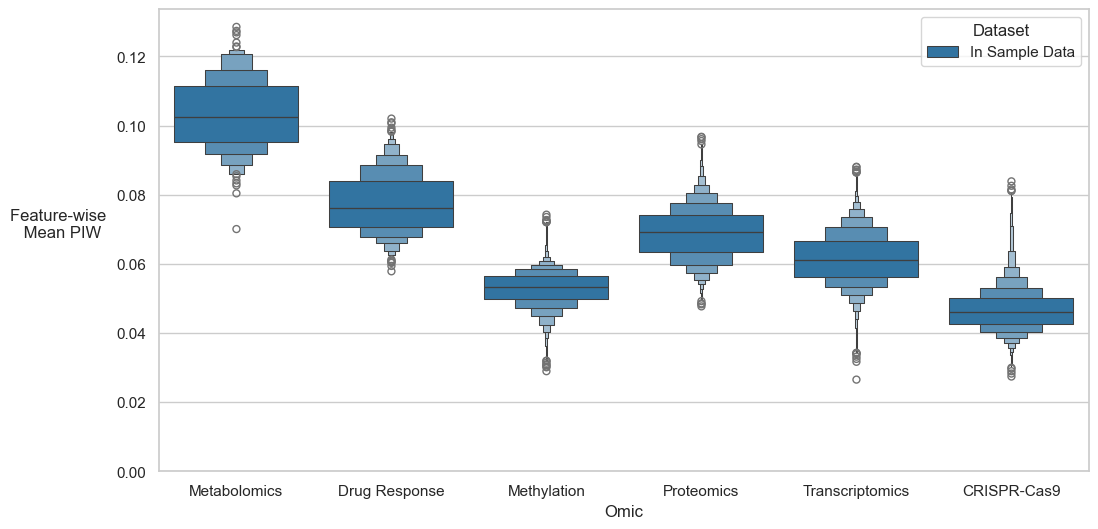

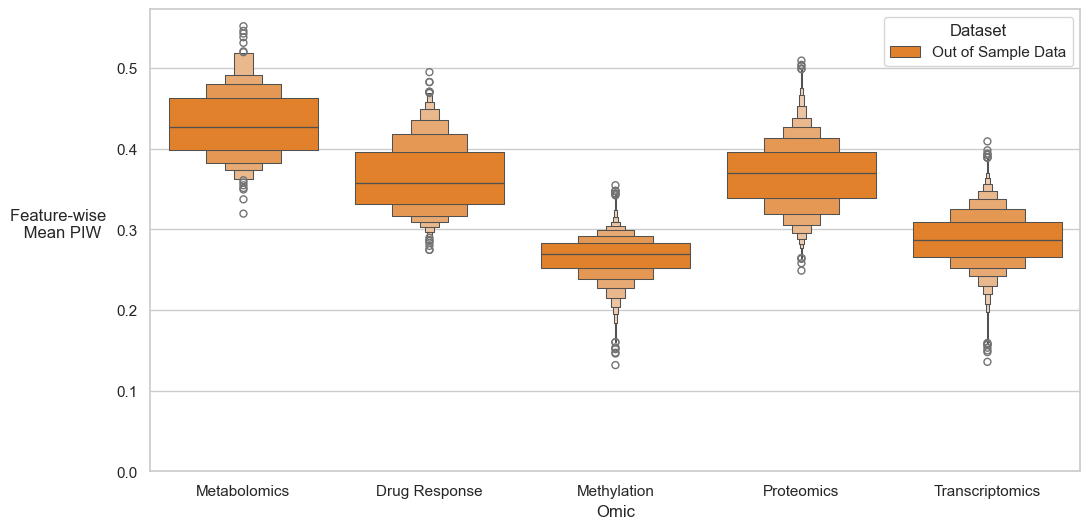

In [6]:
op.plot_distribution(m, "sharpness", settings=("IS",), ylabel="Feature-wise \n Mean PIW", figsize=(12, 6))
op.plot_distribution(m, "sharpness", settings=("OOD",), ylabel="Feature-wise \n Mean PIW", figsize=(12, 6))

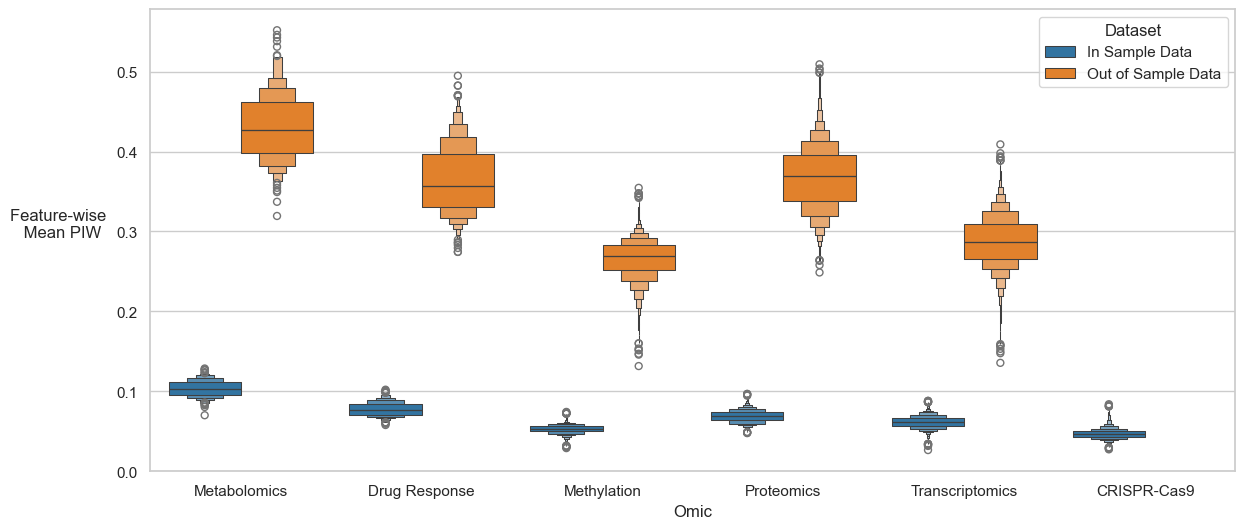

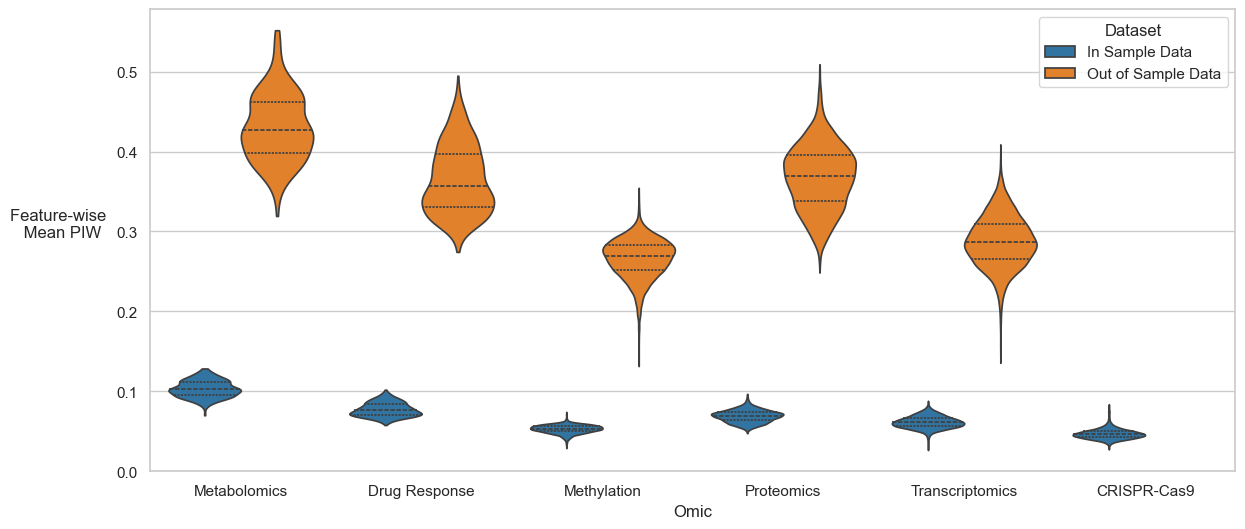

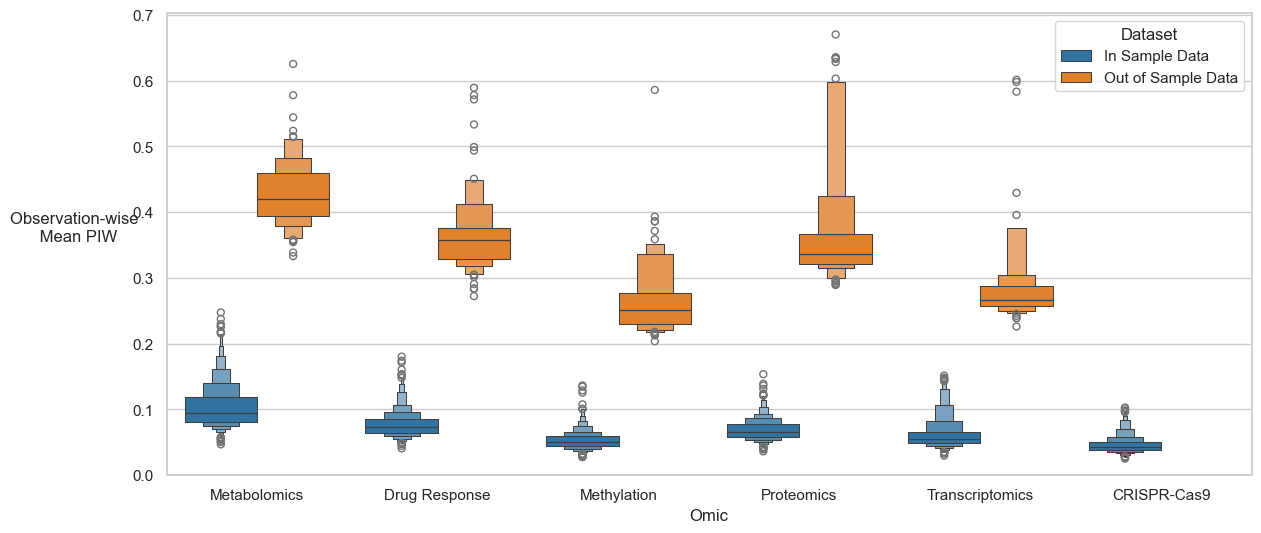

In [7]:
op.plot_distribution(m, "sharpness", ylabel="Feature-wise \n Mean PIW")
op.plot_distribution(m, "sharpness", kind="violin", ylabel="Feature-wise \n Mean PIW")
op.plot_distribution(m, "sharpness", axis=1, ylabel="Observation-wise \n Mean PIW")

Z-score outliers (|z| > 3) of the in-sample PIW at feature, observation and datapoint level.

In [8]:
for omic in cfg.CONTINUOUS:
    op.sharpness_outlier_report(m, omic, "IS")

--- Outliers for metabolomics (IS) ---
Feature mean outliers: ['adenine']
Observation mean outliers: ['SIDM00029', 'SIDM00840', 'SIDM00862', 'SIDM00914', 'SIDM01236', 'SIDM01553', 'SIDM01602', 'SIDM01603', 'SIDM01657', 'SIDM01668', 'SIDM01672', 'SIDM01675', 'SIDM01771']
Individual datapoint outliers (count 2969):
  Obs: SIDM00001, Feature: uridine, Value: 0.2221815556287765
  Obs: SIDM00001, Feature: hexoses (HILIC pos), Value: 0.2188951224088668
  Obs: SIDM00005, Feature: uridine, Value: 0.2196356774307786
  Obs: SIDM00005, Feature: taurine, Value: 0.2435885965824126
  Obs: SIDM00005, Feature: myristoylcarnitine, Value: 0.219497948884964
  Obs: SIDM00005, Feature: palmitoylcarnitine, Value: 0.2282225012779233
  Obs: SIDM00005, Feature: oleylcarnitine, Value: 0.2210140526294708
  Obs: SIDM00005, Feature: C34:1 PC, Value: 0.2224100977182388
  Obs: SIDM00005, Feature: C18:1 CE, Value: 0.2160964053124189
  Obs: SIDM00029, Feature: 4-pyridoxate, Value: 0.2327832840848713
--- Outliers for d

Individual datapoint outliers (count 190784):
  Obs: SIDM00001, Feature: ACOX3, Value: 0.1075118452310561
  Obs: SIDM00001, Feature: ACSF3, Value: 0.1115929484367368
  Obs: SIDM00001, Feature: AKNA, Value: 0.1120935901999473
  Obs: SIDM00001, Feature: ANGPTL6, Value: 0.1177994549274443
  Obs: SIDM00001, Feature: APOA5, Value: 0.1181215614080428
  Obs: SIDM00001, Feature: ARHGAP9, Value: 0.1061053872108459
  Obs: SIDM00001, Feature: ARRDC3, Value: 0.1040875077247619
  Obs: SIDM00001, Feature: B3GALT4, Value: 0.1187967598438262
  Obs: SIDM00001, Feature: B3GNT7, Value: 0.1265911102294921
  Obs: SIDM00001, Feature: BGLAP, Value: 0.1055589109659194
--- Outliers for proteomics (IS) ---
Feature mean outliers: ['EIF4A3', 'NUDT21', 'RPL10A', 'RPL15', 'RPL18', 'RPL18A', 'RPL27', 'RPL3', 'RPL30', 'RPL4', 'RPL7', 'RPL7A', 'RPS13', 'RPS15A', 'RPS16', 'RPS9']
Observation mean outliers: ['SIDM00309', 'SIDM00311', 'SIDM00361', 'SIDM00399', 'SIDM00400', 'SIDM00445', 'SIDM00518', 'SIDM00584', 'SIDM0062

Individual datapoint outliers (count 297037):
  Obs: SIDM00001, Feature: BAIAP2, Value: 0.1378525376319883
  Obs: SIDM00001, Feature: BLK, Value: 0.1446997046470639
  Obs: SIDM00001, Feature: CD180, Value: 0.148803675174713
  Obs: SIDM00001, Feature: CD48, Value: 0.1489557504653929
  Obs: SIDM00001, Feature: CD53, Value: 0.1473527610301968
  Obs: SIDM00001, Feature: CD79A, Value: 0.1454728066921236
  Obs: SIDM00001, Feature: CD79B, Value: 0.1468551576137544
  Obs: SIDM00001, Feature: CD80, Value: 0.1470274448394772
  Obs: SIDM00001, Feature: CIITA, Value: 0.1560966372489929
  Obs: SIDM00001, Feature: CLEC17A, Value: 0.1607299625873568
--- Outliers for crisprcas9 (IS) ---
Feature mean outliers: ['AARS2', 'APOBEC3B', 'ATP5F1B', 'ATP5F1C', 'ATP5ME', 'ATP5PB', 'BCS1L', 'C1QBP', 'C1orf109', 'CARS2', 'CHCHD4', 'COA3', 'COA6', 'COA7', 'COQ4', 'COQ7', 'COX10', 'COX11', 'COX14', 'COX15', 'COX16', 'COX4I1', 'COX5B', 'COX6B1', 'COX6C', 'COX7C', 'CYB5A', 'CYC1', 'CYCS', 'DAP3', 'DARS2', 'DDX28', '

Individual datapoint outliers (count 221610):
  Obs: SIDM00001, Feature: AARS2, Value: 0.1046866029500961
  Obs: SIDM00001, Feature: ACAD9, Value: 0.1006041727960109
  Obs: SIDM00001, Feature: ACAP3, Value: 0.098487839102745
  Obs: SIDM00001, Feature: ADGRV1, Value: 0.094272743165493
  Obs: SIDM00001, Feature: ADPRHL1, Value: 0.0956123702228068
  Obs: SIDM00001, Feature: AFF1, Value: 0.0998112976551054
  Obs: SIDM00001, Feature: AGAP3, Value: 0.1010189369320869
  Obs: SIDM00001, Feature: AGFG1, Value: 0.1014336019754409
  Obs: SIDM00001, Feature: AGPS, Value: 0.0957275331020355
  Obs: SIDM00001, Feature: AK2, Value: 0.1021591961383818


## 4. Calibration (ENCE) distributions

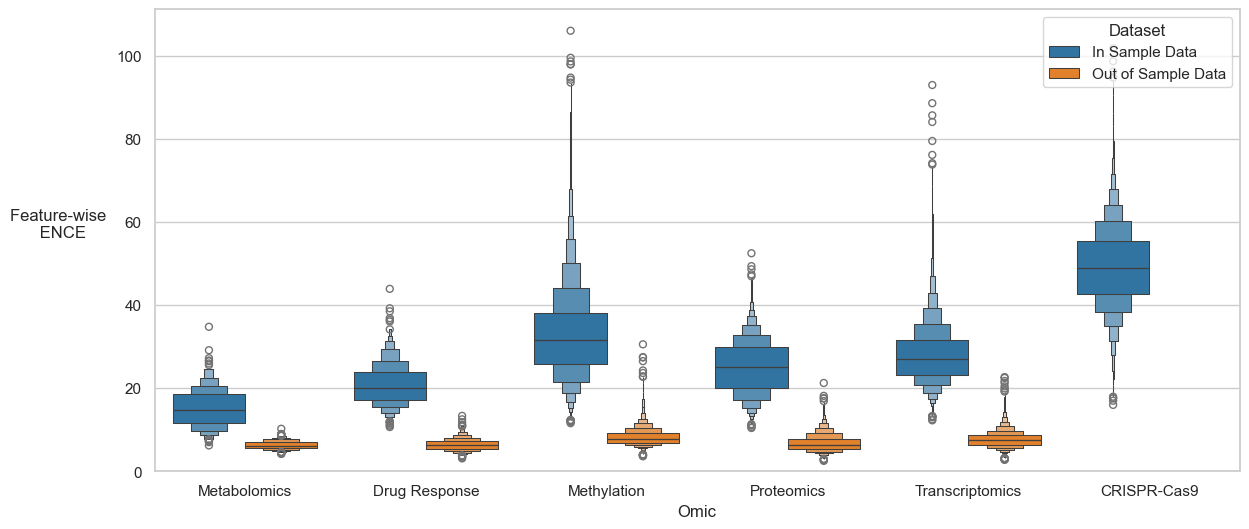

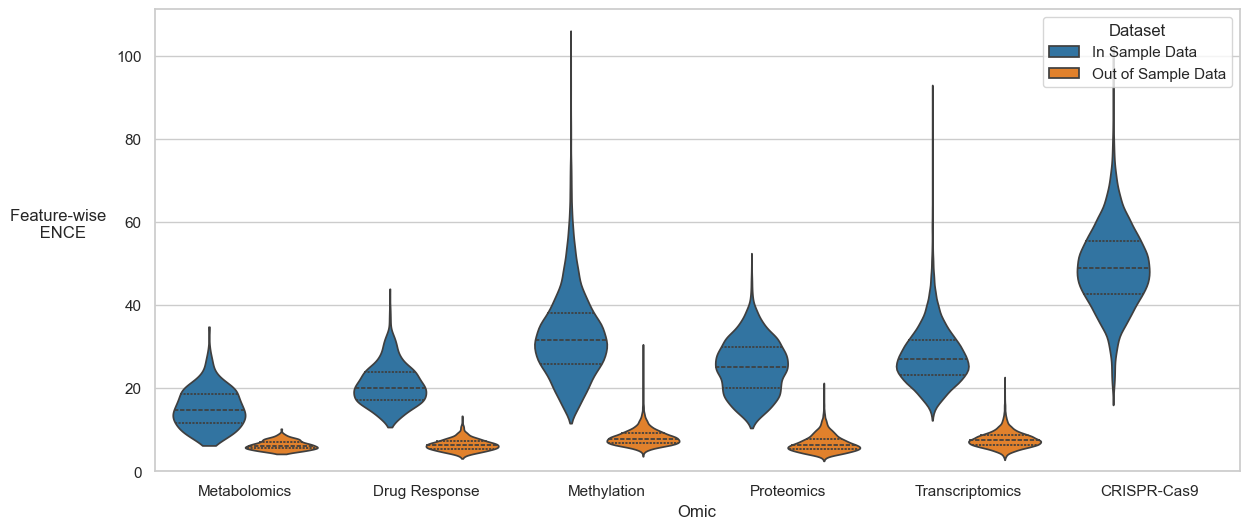

In [9]:
op.plot_distribution(m, "calibration", ylabel="Feature-wise \n ENCE")
op.plot_distribution(m, "calibration", kind="violin", ylabel="Feature-wise \n ENCE")

Methylation alone (its scale hides the other omics above); only positive values.

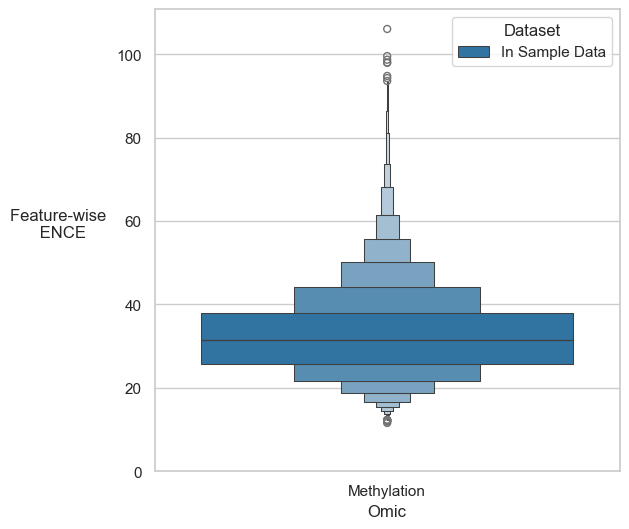

In [10]:
op.plot_distribution(m, "calibration", omics=["methylation"], settings=("IS",), positive_only=True, ylabel="Feature-wise \n ENCE")

One point per omic: mean feature PIW against mean ENCE.

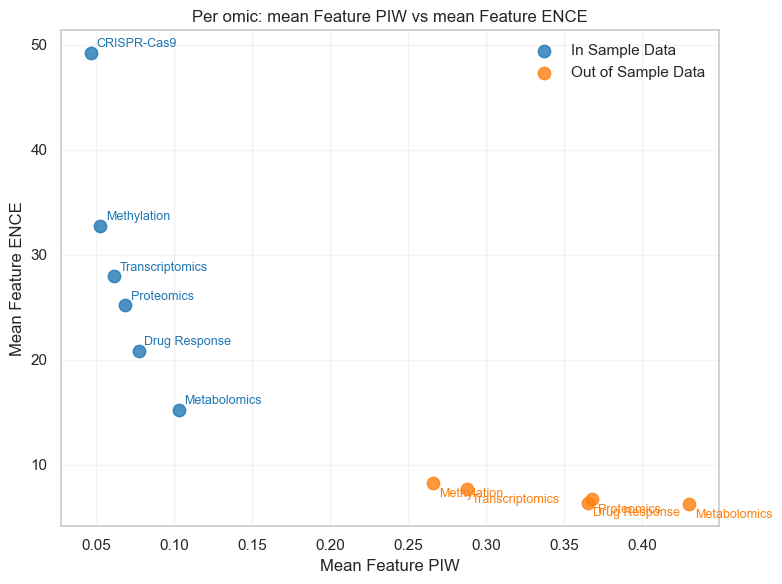

In [11]:
op.plot_omic_means(m, x="sharpness", y="calibration")

## 5. Scoring rule distributions (CRPS; log score for copy number)

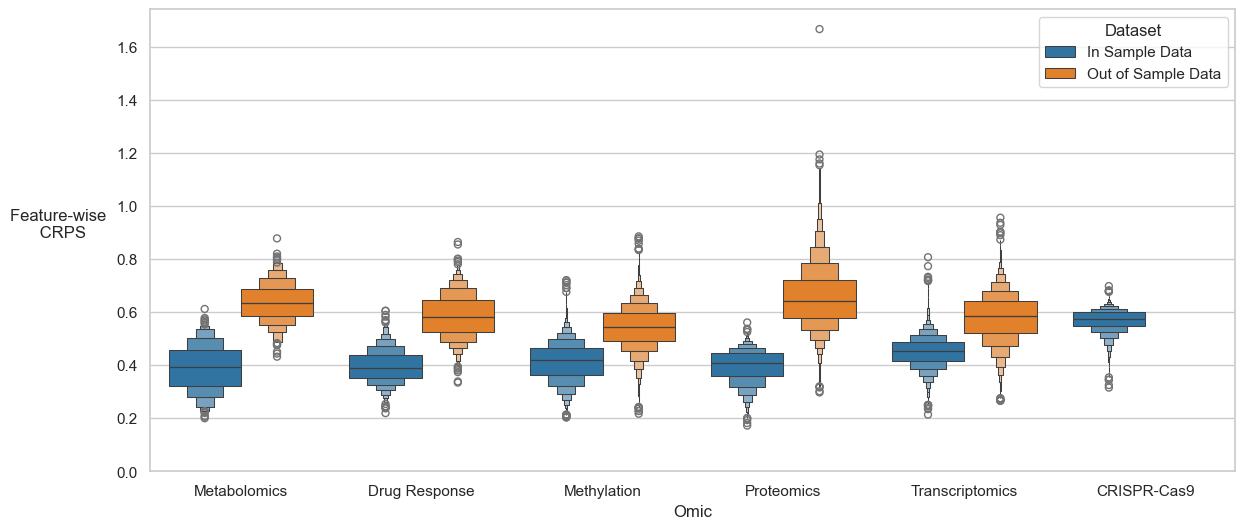

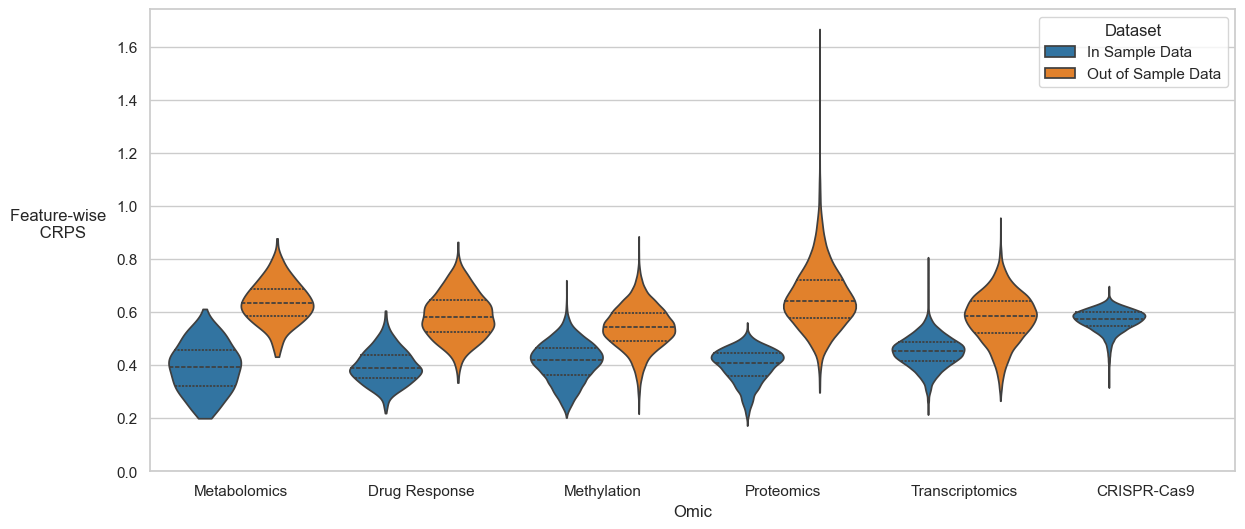

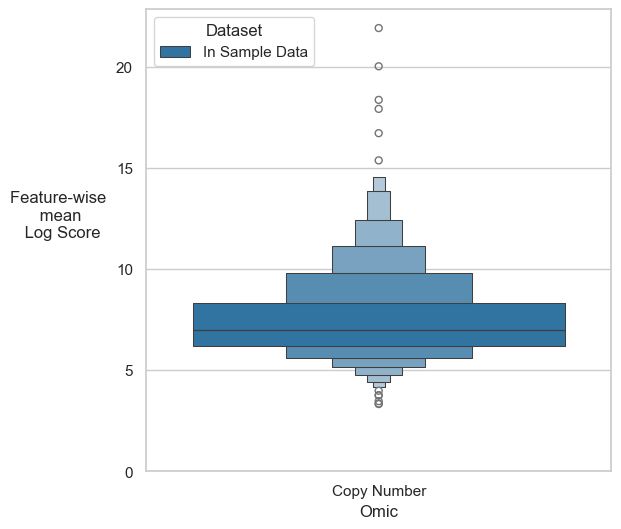

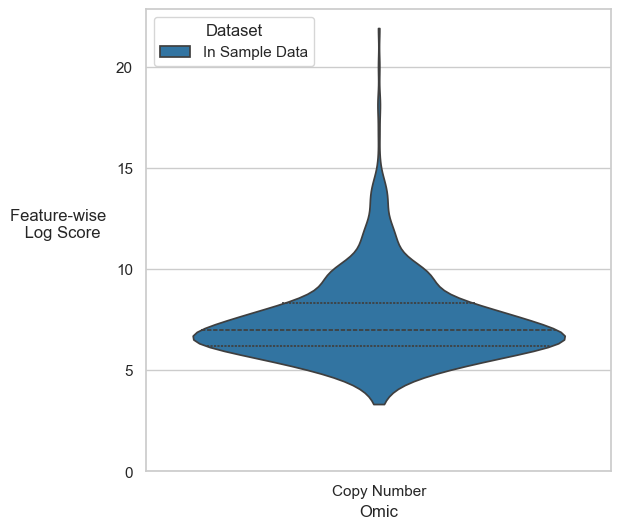

In [12]:
op.plot_distribution(m, "scoring", ylabel="Feature-wise \n CRPS")
op.plot_distribution(m, "scoring", kind="violin", ylabel="Feature-wise \n CRPS")
op.plot_distribution(m, "scoring", omics=["copynumber"], ylabel="Feature-wise \n mean \n Log Score", legend_loc="upper left")
op.plot_distribution(m, "scoring", omics=["copynumber"], kind="violin", ylabel="Feature-wise \n Log Score", legend_loc="upper left")

## 6. Feature-level relationships, one panel per omic
Each point is a feature; trend line (least squares) with 95% confidence band and R^2, and marginal histograms.

**PIW vs ENCE, coloured by the scoring rule.**

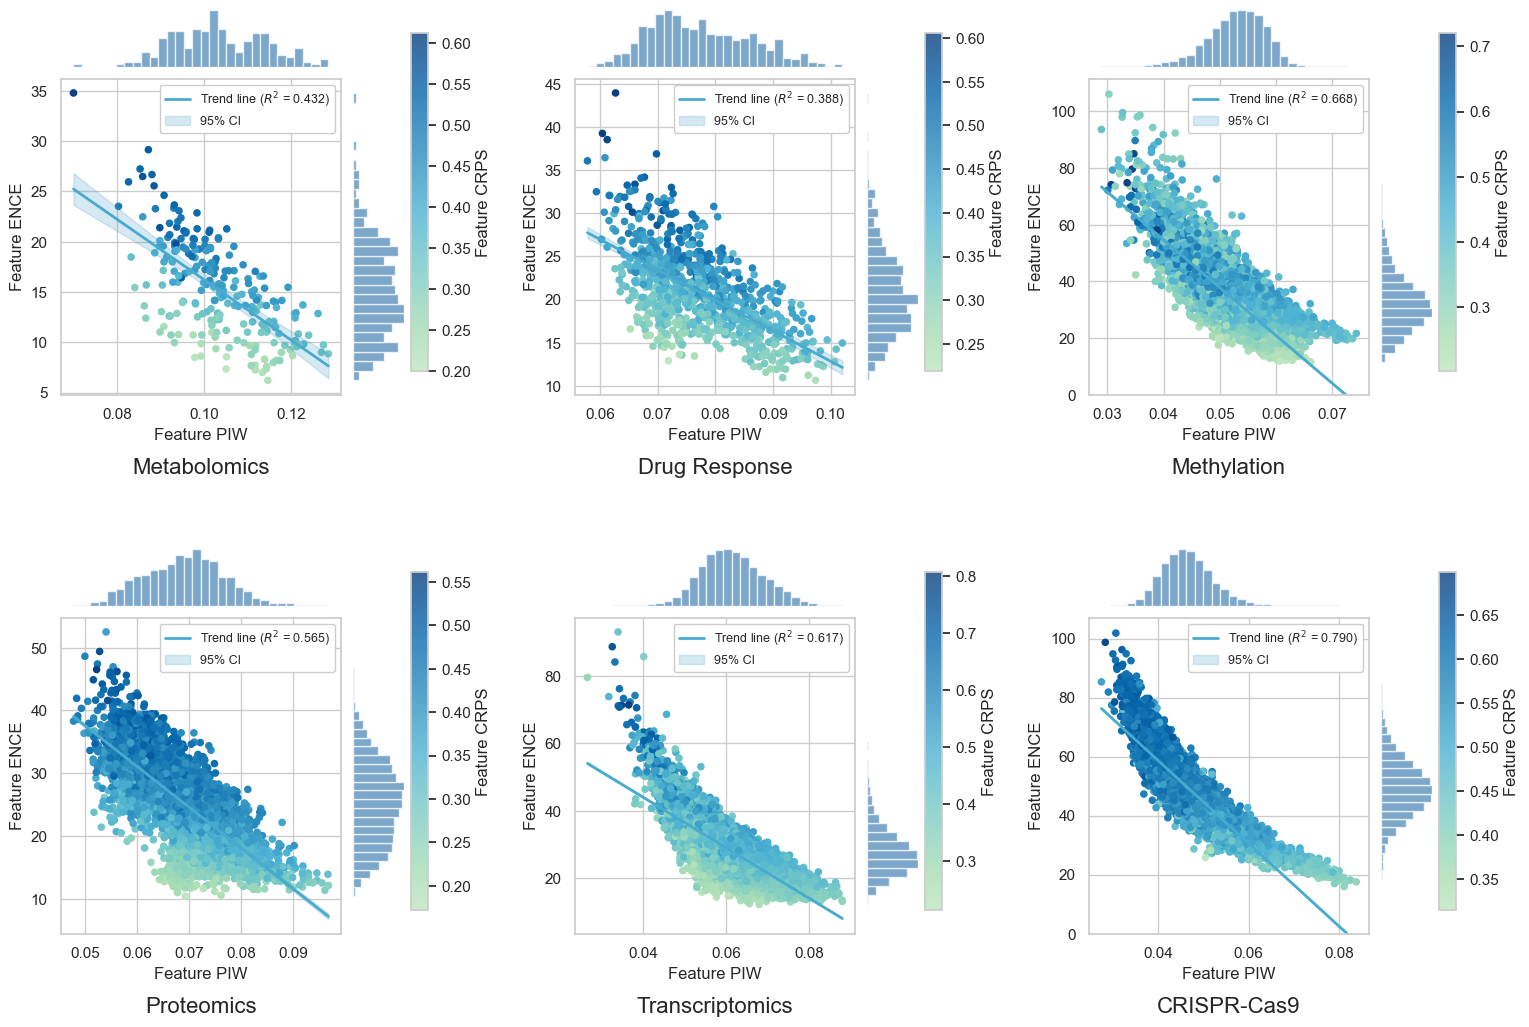

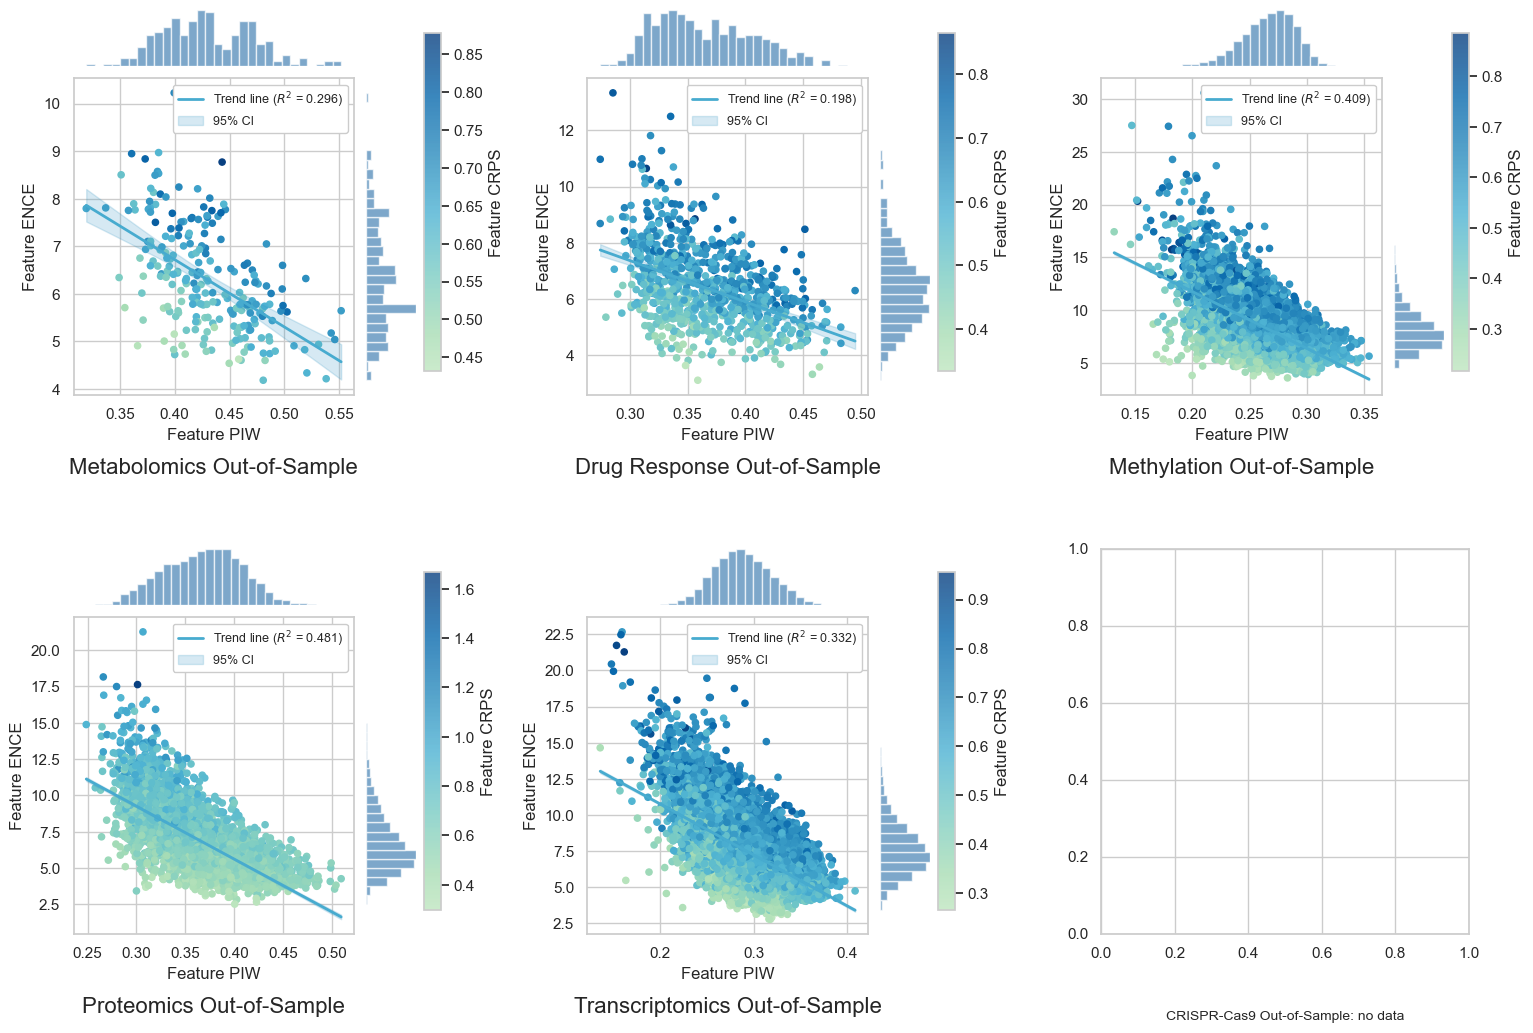

In [13]:
op.grid_scatter(m, "IS", x="sharpness", y="calibration", c="scoring")
op.grid_scatter(m, "OOD", x="sharpness", y="calibration", c="scoring", title_suffix=" Out-of-Sample")

All seven omics. In-sample thinned to ~1200 plotted points per panel; OOD with density contours.

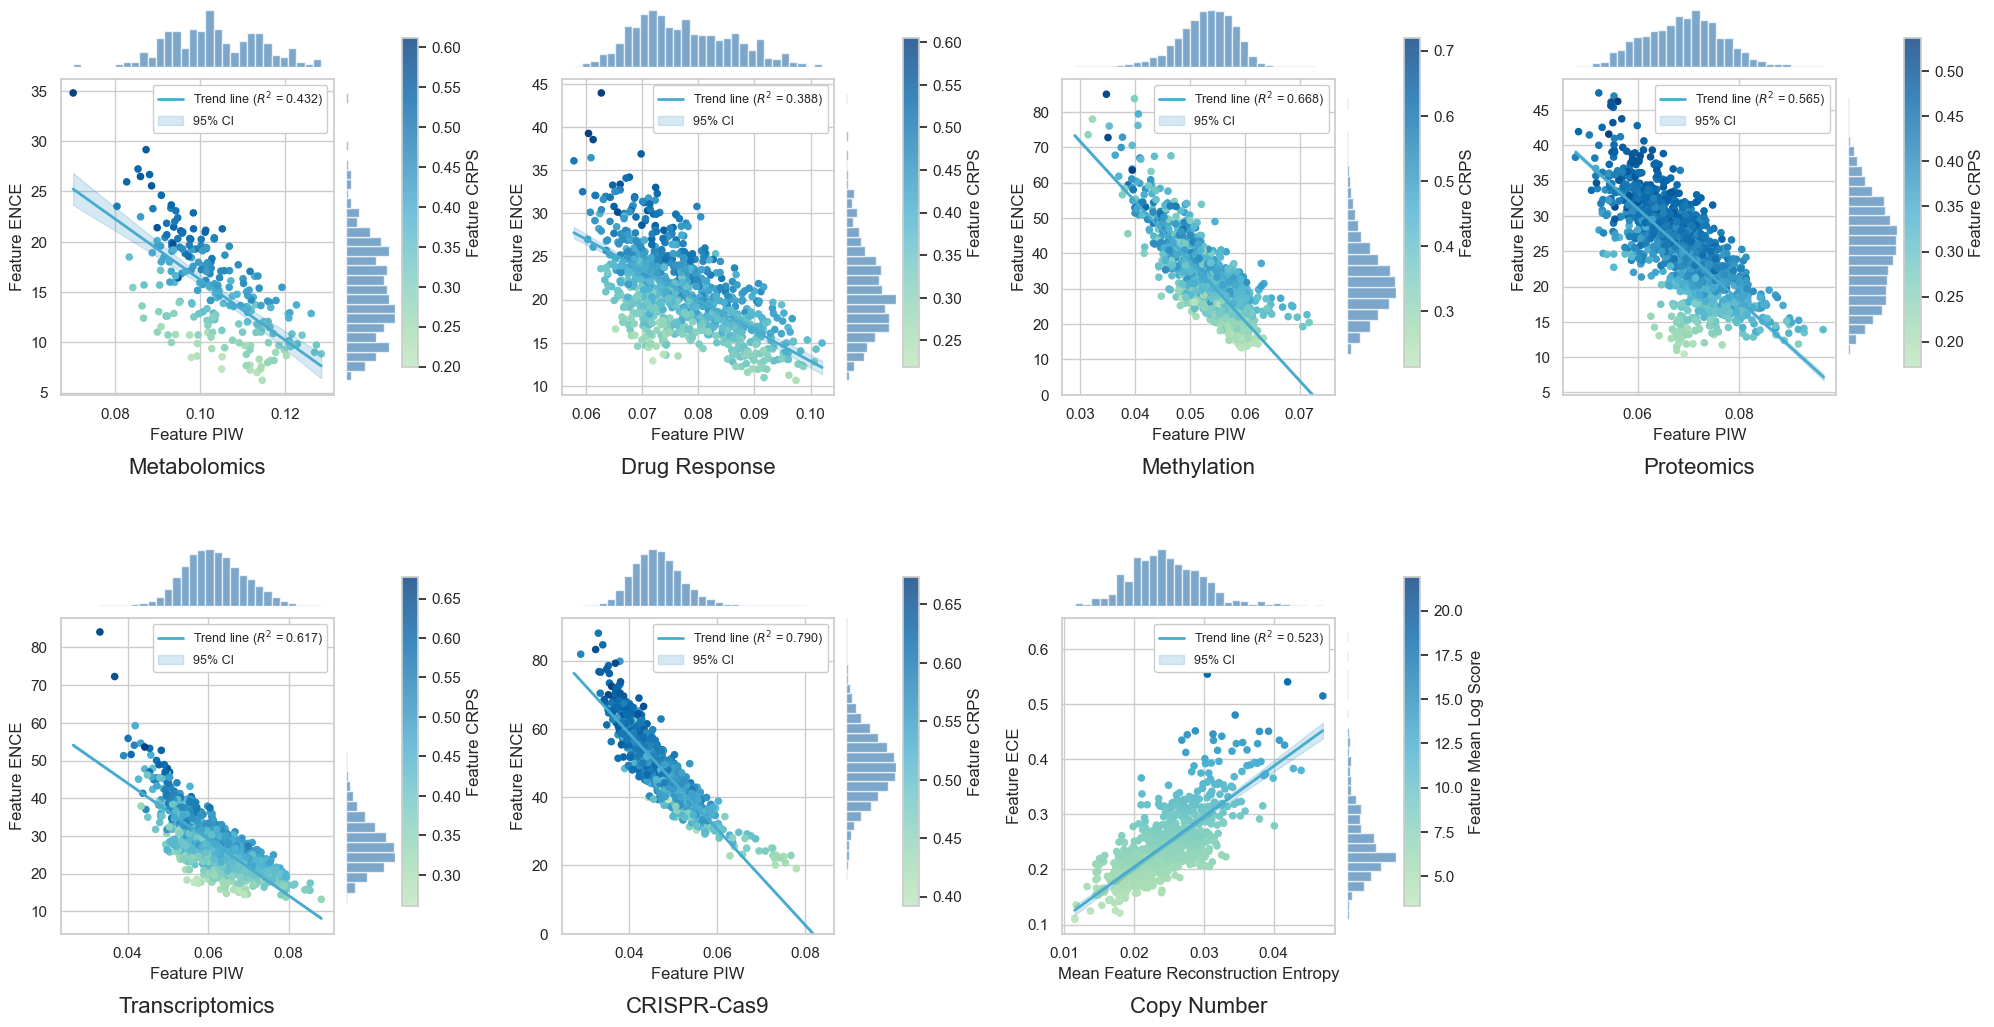

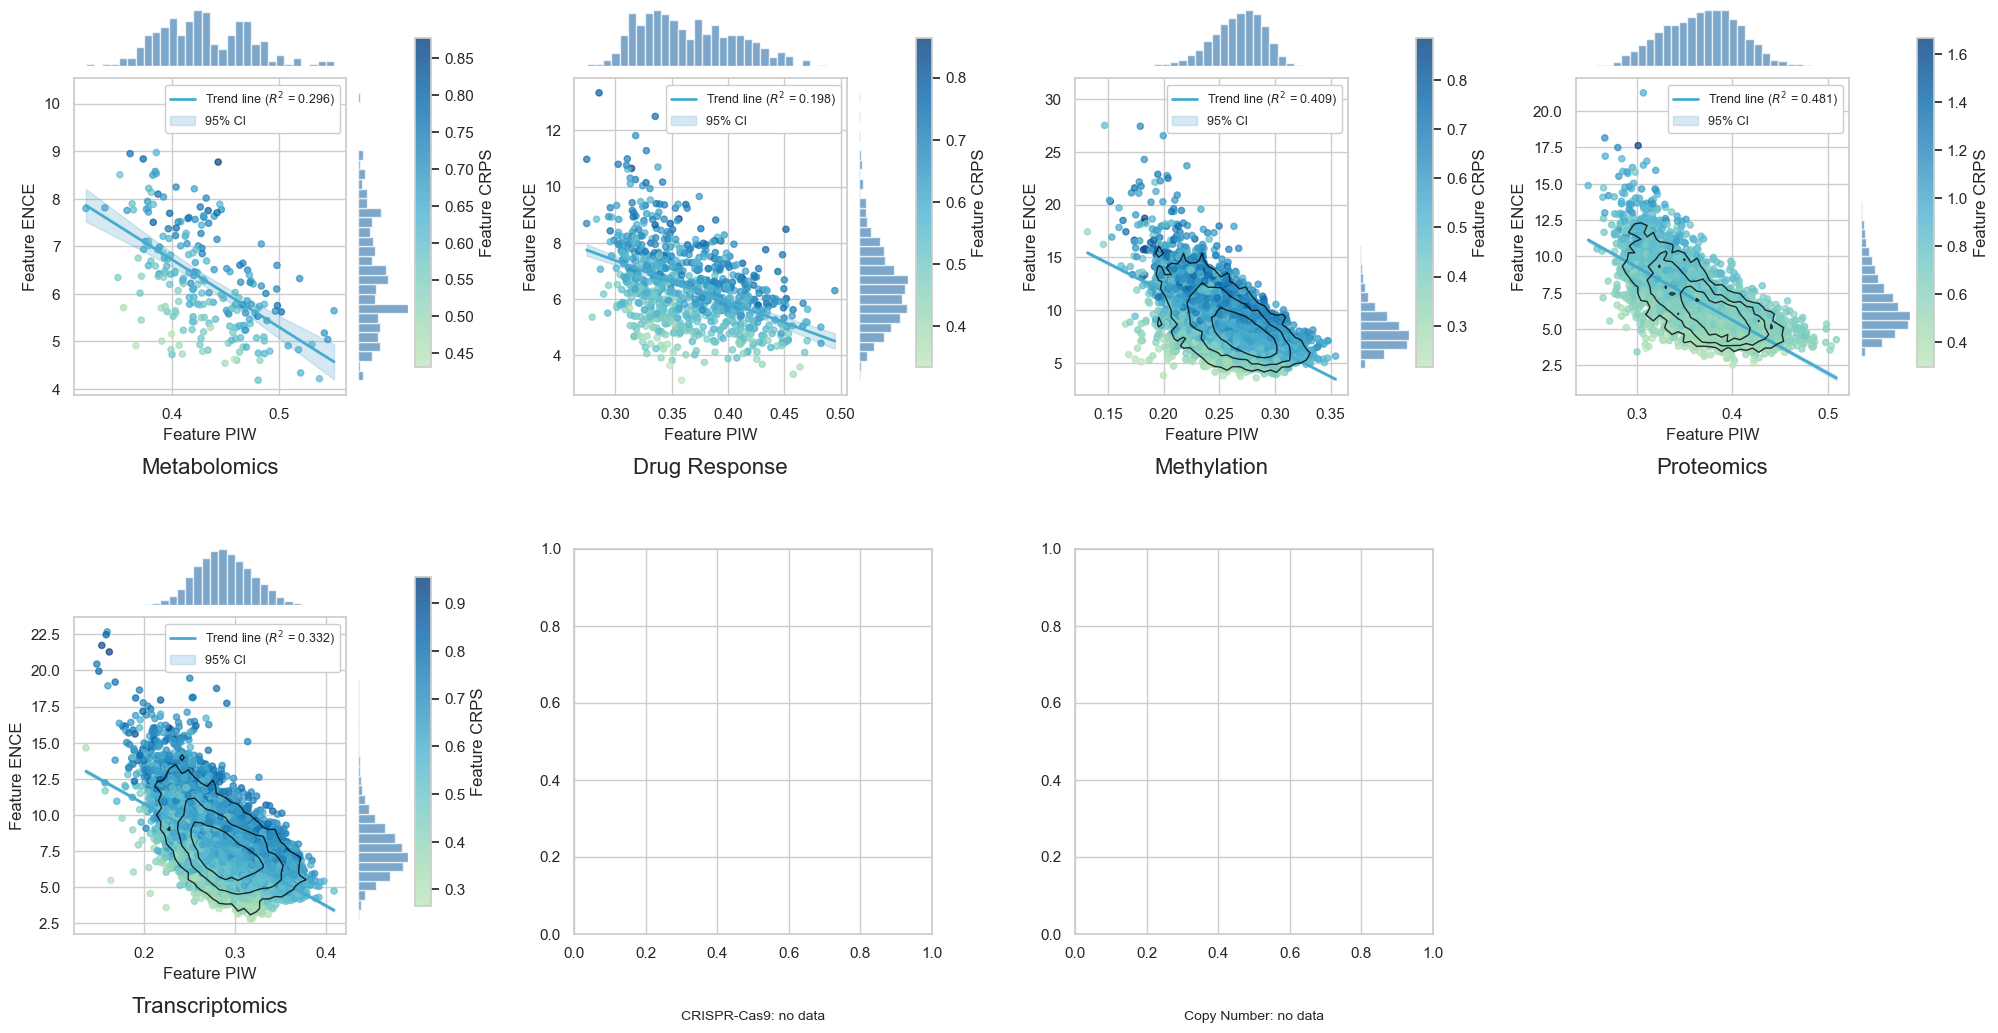

In [14]:
op.grid_scatter(m, "IS", x="sharpness", y="calibration", c="scoring", omics=cfg.OMICS, sample_max=1200, trend_x0=0)
op.grid_scatter(m, "OOD", x="sharpness", y="calibration", c="scoring", omics=cfg.OMICS, alpha=0.7,
                contour=["methylation", "proteomics", "transcriptomics", "crisprcas9"])

**Error (RMSE; balanced accuracy) vs calibration**, coloured by the percentage of missing values in the ground truth
(single colour for omics without missing values).

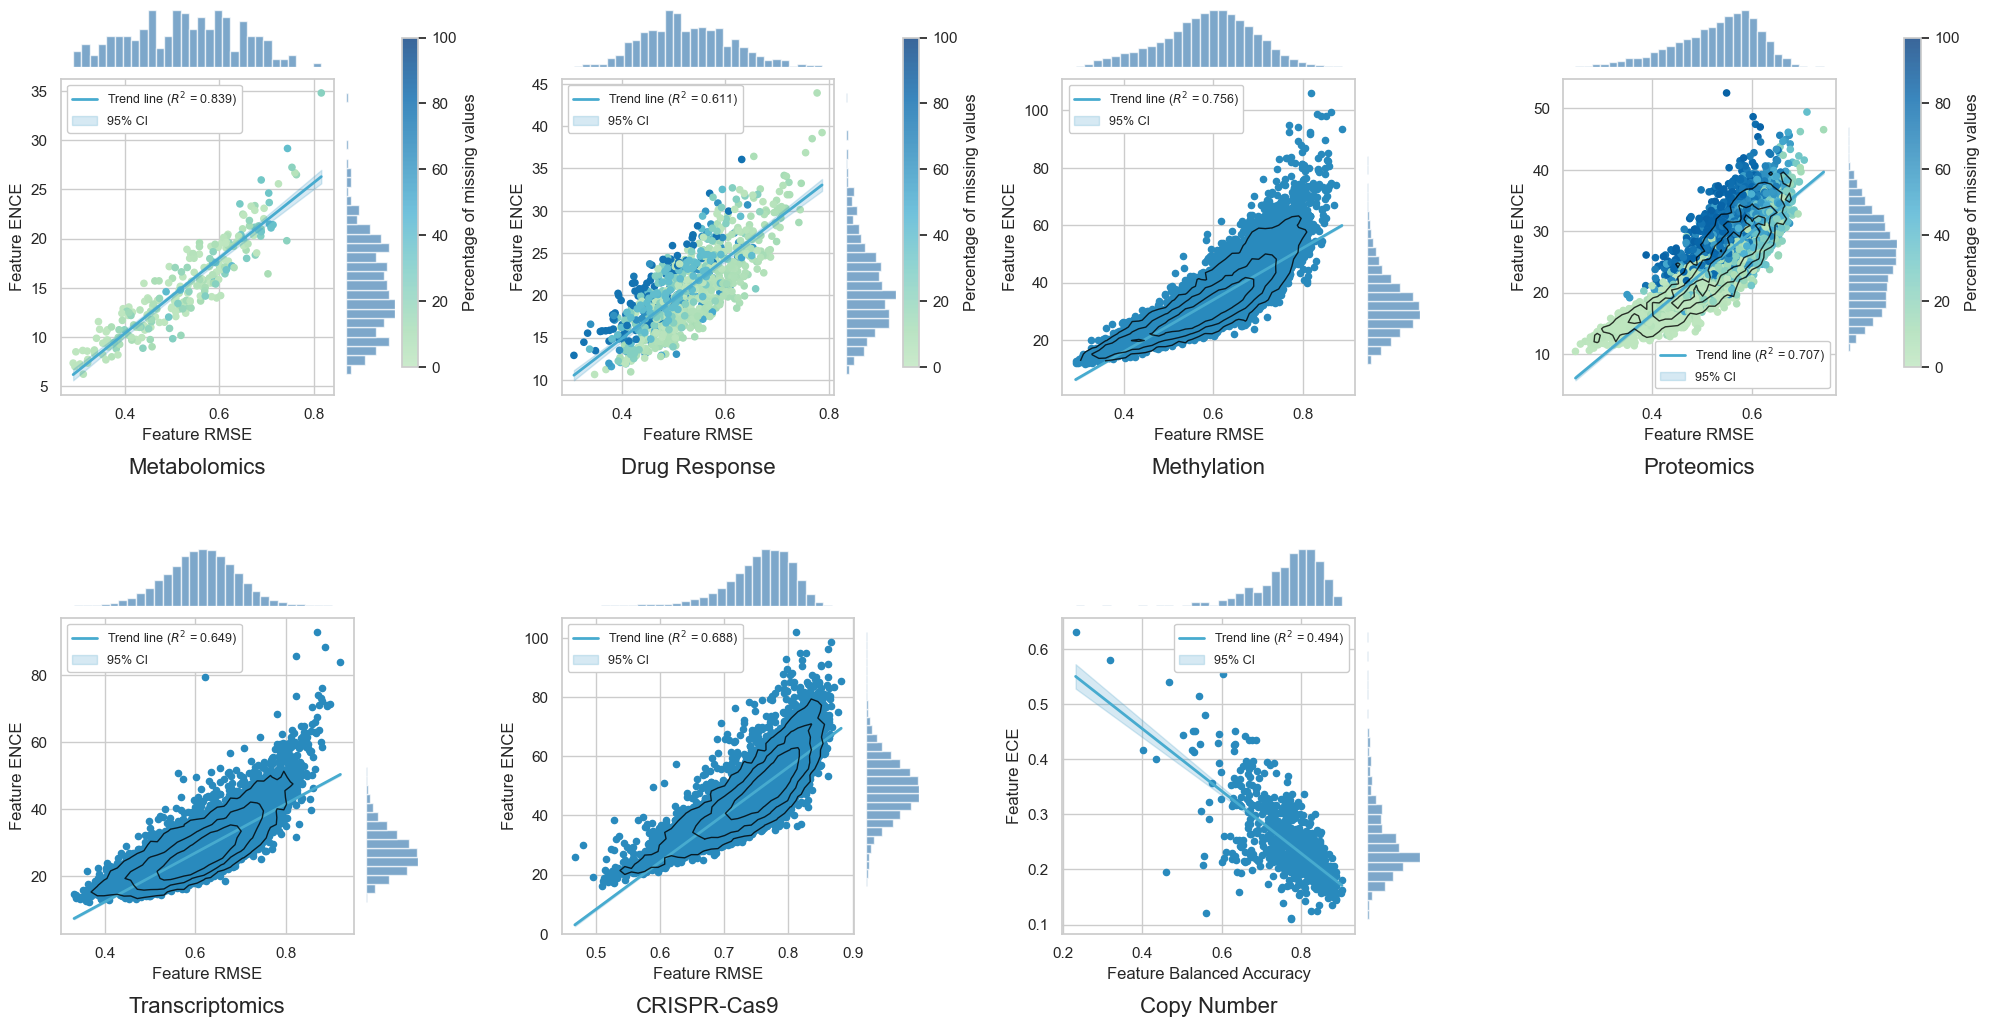

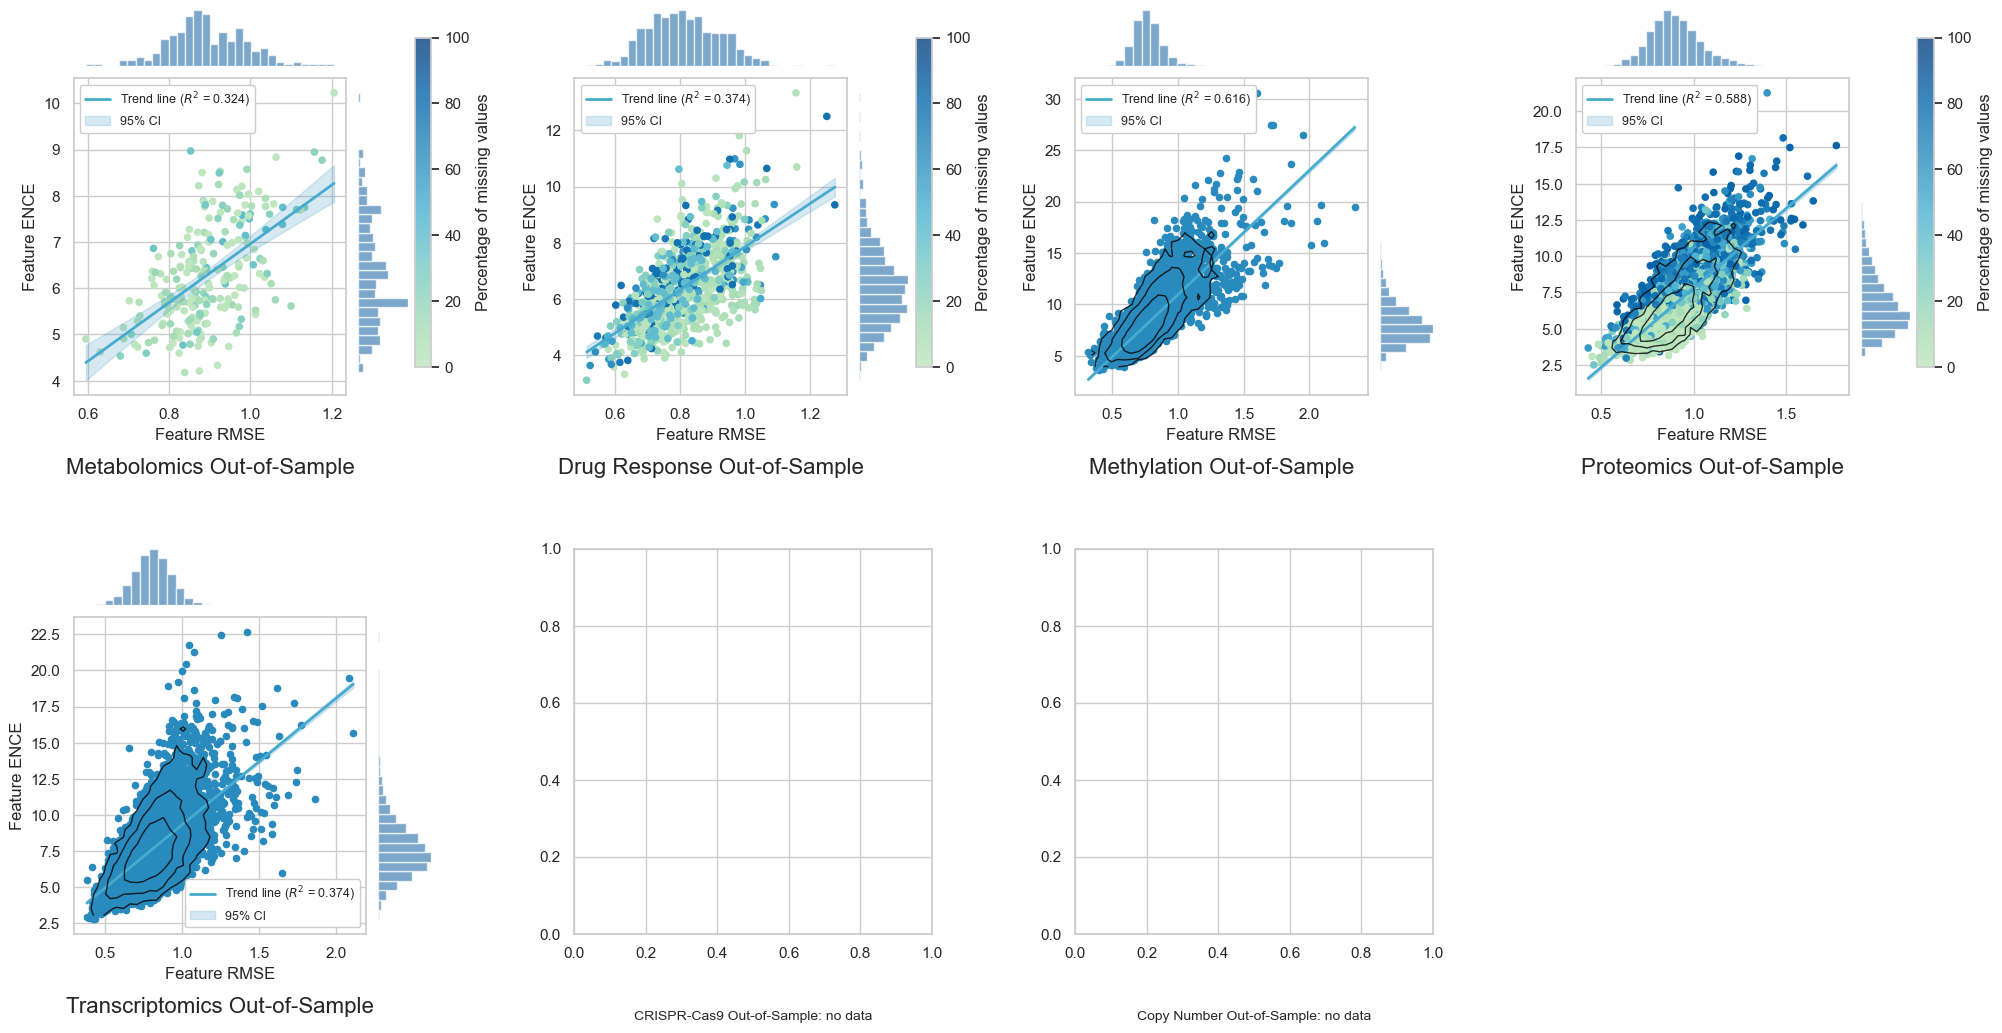

In [15]:
for setting in cfg.SETTINGS:
    op.grid_scatter(m, setting, x="error", y="calibration", c="missing", omics=cfg.OMICS, info=info,
                    contour=["methylation", "proteomics", "transcriptomics", "crisprcas9"],
                    title_suffix="" if setting == "IS" else " Out-of-Sample")

Same, coloured by the scoring rule, with a log ENCE axis and no trend line for methylation and CRISPR-Cas9.

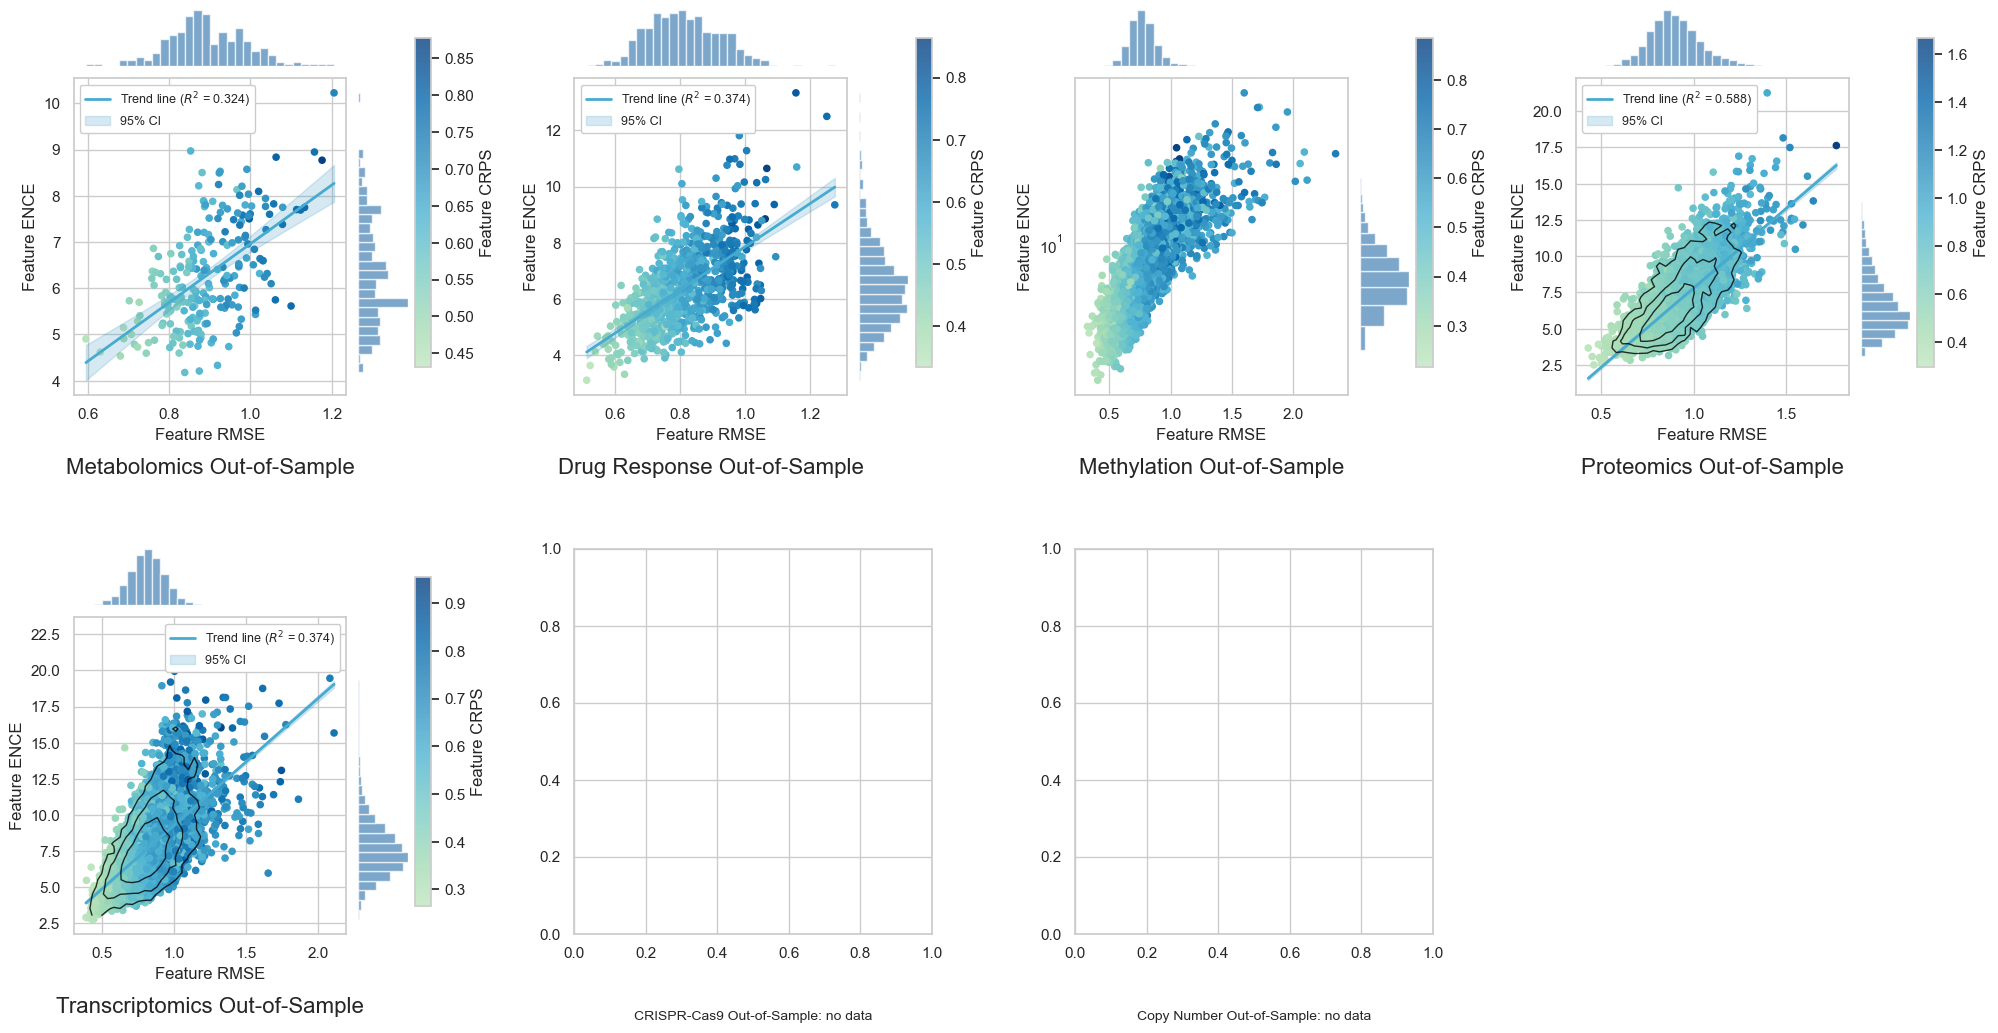

In [16]:
op.grid_scatter(m, "OOD", x="error", y="calibration", c="scoring", omics=cfg.OMICS,
                log_y=["methylation", "crisprcas9"], no_trend=["methylation", "crisprcas9"],
                contour=["proteomics", "transcriptomics"], title_suffix=" Out-of-Sample")

## 7. Correlation between feature-level metrics, per omic

Pearson correlation matrix for Out of Sample Data metabolomics:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance,Missing \n Values
Feature \nPIW,1.00,-0.54,0.16,0.13,-0.05,-0.07
ENCE,-0.54,1.00,0.54,0.57,-0.06,0.19
CRPS,0.16,0.54,1.00,0.91,-0.03,0.27
Feature\nRMSE,0.13,0.57,0.91,1.00,-0.15,0.19
Original \n Feature's \n Variance,-0.05,-0.06,-0.03,-0.15,1.00,0.03
Missing \n Values,-0.07,0.19,0.27,0.19,0.03,1.00


Pearson correlation matrix for Out of Sample Data drugresponse:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance,Missing \n Values
Feature \nPIW,1.00,-0.45,0.11,0.19,0.20,-0.33
ENCE,-0.45,1.00,0.60,0.61,-0.24,0.13
CRPS,0.11,0.60,1.00,0.91,-0.15,0.03
Feature\nRMSE,0.19,0.61,0.91,1.00,-0.15,-0.07
Original \n Feature's \n Variance,0.20,-0.24,-0.15,-0.15,1.00,0.03
Missing \n Values,-0.33,0.13,0.03,-0.07,0.03,1.00


Pearson correlation matrix for Out of Sample Data methylation:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance
Feature \nPIW,1.00,-0.64,-0.02,-0.31,-0.01
ENCE,-0.64,1.00,0.52,0.78,-0.04
CRPS,-0.02,0.52,1.00,0.69,-0.00
Feature\nRMSE,-0.31,0.78,0.69,1.00,-0.14
Original \n Feature's \n Variance,-0.01,-0.04,-0.00,-0.14,1.00


Pearson correlation matrix for Out of Sample Data proteomics:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance,Missing \n Values
Feature \nPIW,1.00,-0.69,-0.43,-0.37,-0.12,-0.76
ENCE,-0.69,1.00,0.79,0.77,-0.06,0.63
CRPS,-0.43,0.79,1.00,0.94,-0.21,0.48
Feature\nRMSE,-0.37,0.77,0.94,1.00,-0.23,0.40
Original \n Feature's \n Variance,-0.12,-0.06,-0.21,-0.23,1.00,0.13
Missing \n Values,-0.76,0.63,0.48,0.40,0.13,1.00


Pearson correlation matrix for Out of Sample Data transcriptomics:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance
Feature \nPIW,1.00,-0.58,0.06,-0.02,-0.35
ENCE,-0.58,1.00,0.52,0.61,0.02
CRPS,0.06,0.52,1.00,0.86,-0.26
Feature\nRMSE,-0.02,0.61,0.86,1.00,-0.33
Original \n Feature's \n Variance,-0.35,0.02,-0.26,-0.33,1.00


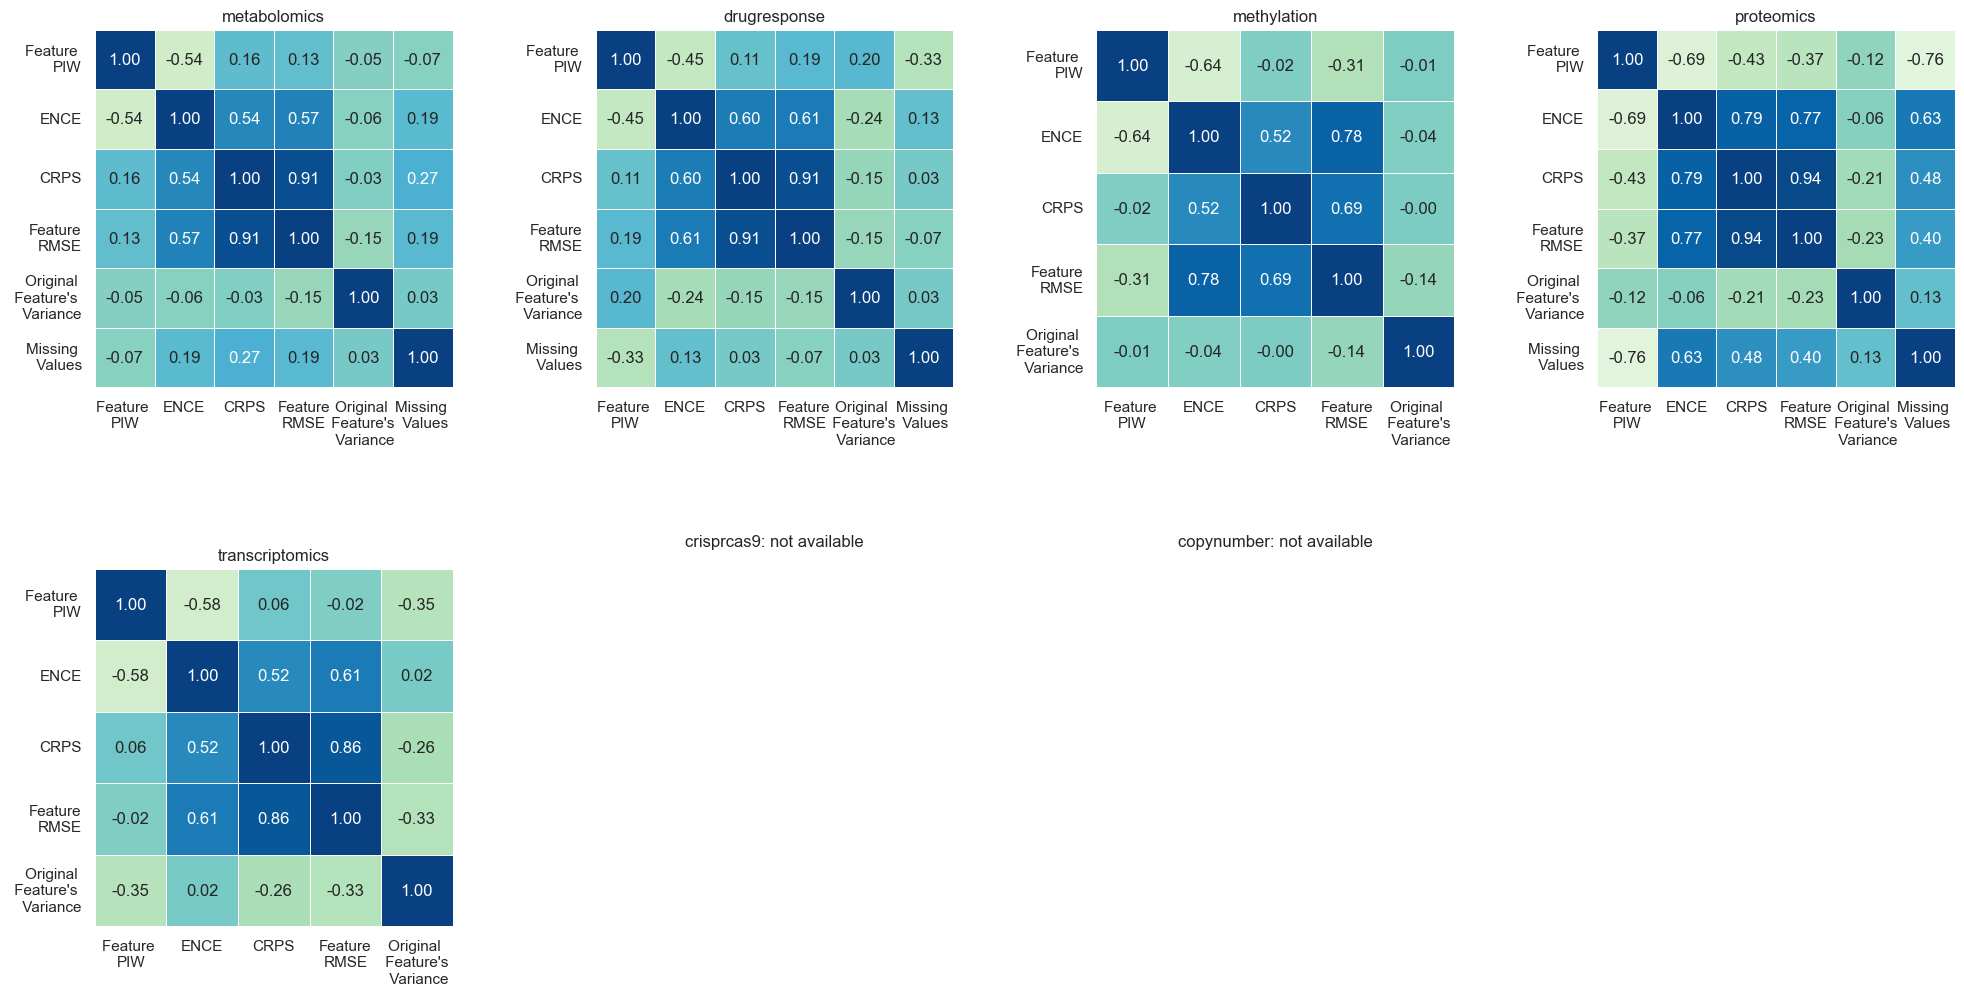

Pearson correlation matrix for In Sample Data metabolomics:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance,Missing \n Values
Feature \nPIW,1.00,-0.66,-0.38,-0.41,-0.05,-0.11
ENCE,-0.66,1.00,0.89,0.92,0.02,0.32
CRPS,-0.38,0.89,1.00,0.99,0.05,0.41
Feature\nRMSE,-0.41,0.92,0.99,1.00,0.03,0.38
Original \n Feature's \n Variance,-0.05,0.02,0.05,0.03,1.00,0.03
Missing \n Values,-0.11,0.32,0.41,0.38,0.03,1.00


Pearson correlation matrix for In Sample Data drugresponse:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance,Missing \n Values
Feature \nPIW,1.00,-0.62,-0.20,-0.17,0.21,-0.30
ENCE,-0.62,1.00,0.77,0.78,-0.38,-0.07
CRPS,-0.20,0.77,1.00,0.97,-0.36,-0.34
Feature\nRMSE,-0.17,0.78,0.97,1.00,-0.39,-0.37
Original \n Feature's \n Variance,0.21,-0.38,-0.36,-0.39,1.00,0.03
Missing \n Values,-0.30,-0.07,-0.34,-0.37,0.03,1.00


Pearson correlation matrix for In Sample Data methylation:


...

,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance
Feature \nPIW,1.00,-0.79,-0.30,-0.45,-0.41
ENCE,-0.79,1.00,0.65,0.81,0.14
CRPS,-0.30,0.65,1.00,0.88,-0.00
Feature\nRMSE,-0.45,0.81,0.88,1.00,-0.10
Original \n Feature's \n Variance,-0.41,0.14,-0.00,-0.10,1.00


Pearson correlation matrix for In Sample Data crisprcas9:


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Original \n Feature's \n Variance
Feature \nPIW,1.00,-0.89,-0.72,-0.82,0.27
ENCE,-0.89,1.00,0.75,0.83,-0.24
CRPS,-0.72,0.75,1.00,0.92,-0.22
Feature\nRMSE,-0.82,0.83,0.92,1.00,-0.27
Original \n Feature's \n Variance,0.27,-0.24,-0.22,-0.27,1.00


Pearson correlation matrix for In Sample Data copynumber:


,Mean Feature\nEntropy,ECE,Feature\nLog Score,Balanced\nAccuracy,Feature\nDiversity
Mean Feature\nEntropy,1.00,0.72,0.69,-0.42,0.52
ECE,0.72,1.00,1.00,-0.70,0.53
Feature\nLog Score,0.69,1.00,1.00,-0.71,0.53
Balanced\nAccuracy,-0.42,-0.70,-0.71,1.00,-0.40
Feature\nDiversity,0.52,0.53,0.53,-0.40,1.00


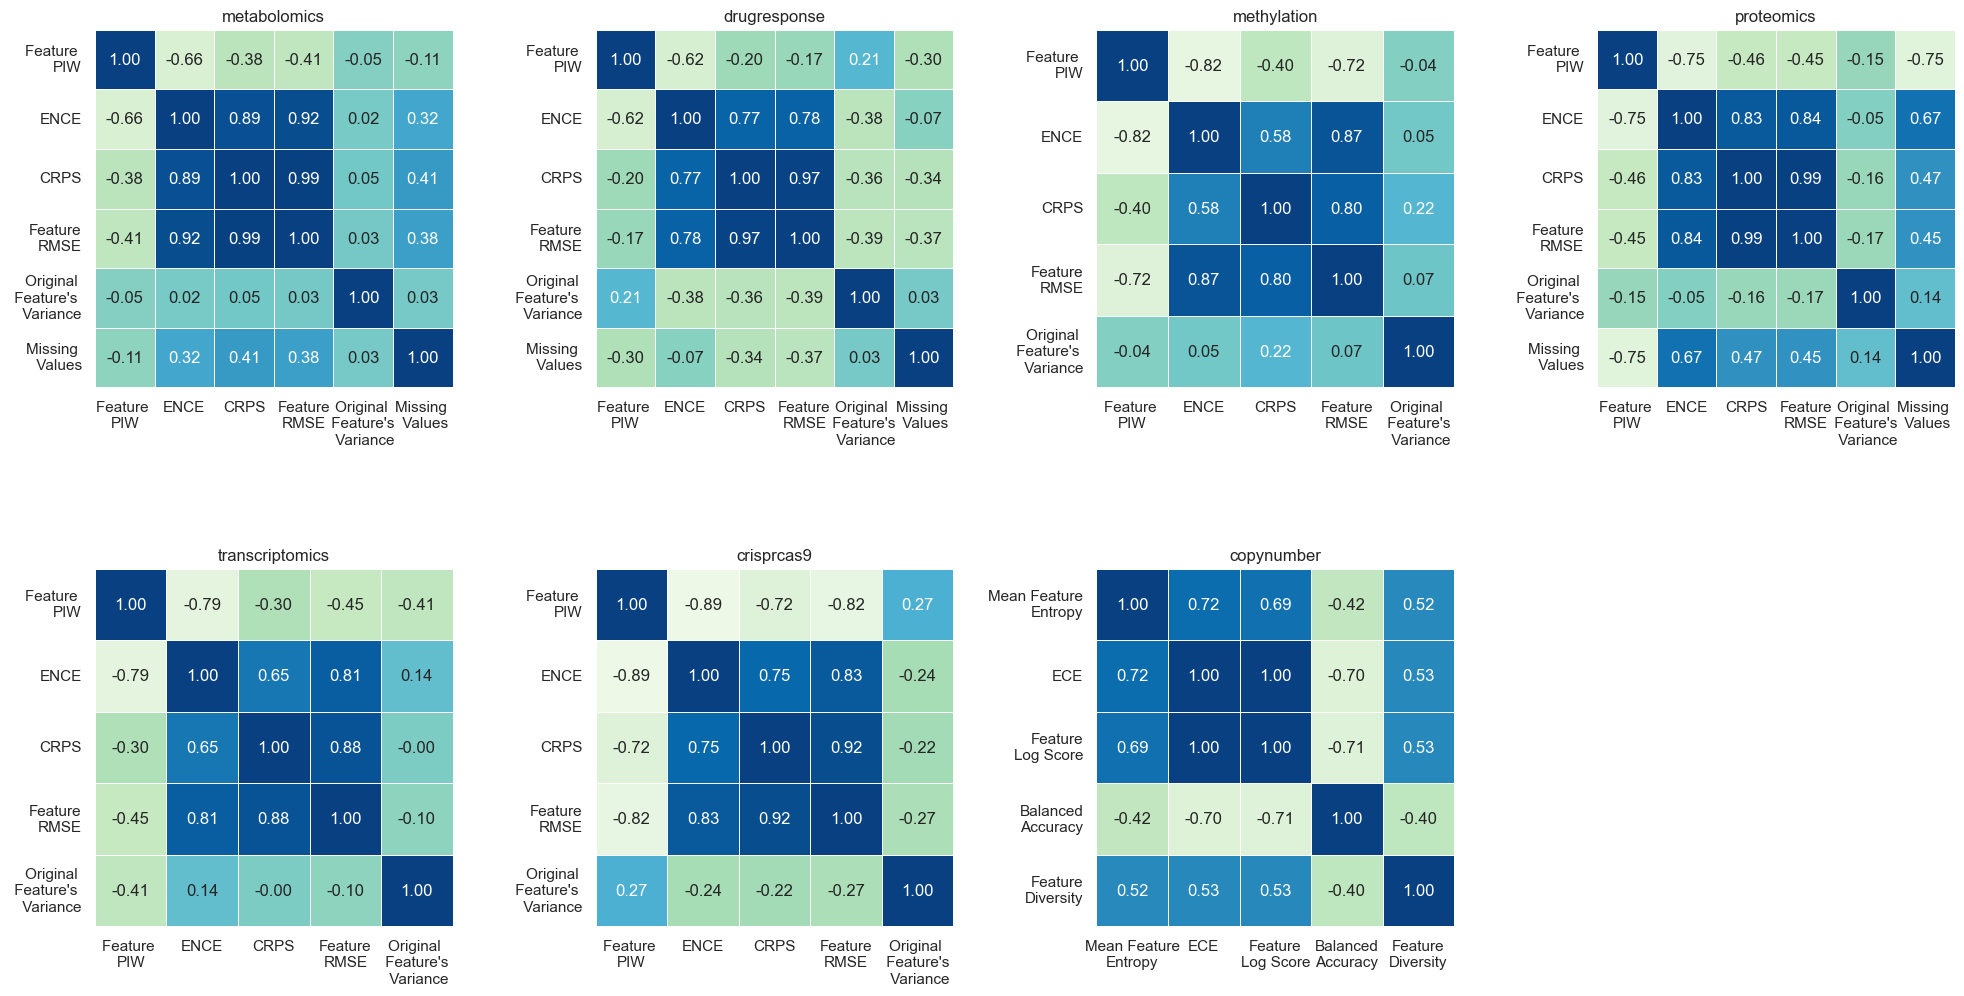

In [17]:
op.corr_grid(m, "OOD", info)
op.corr_grid(m, "IS", info)

## 8. Observation-wise analysis and tissues
Mean sharpness of every observation (cell line) per omic, with the number of omics it has and its tissue.

In [18]:
by_obs = op.mean_sharpness_by_obs(m, tissue, "IS")
display(by_obs)

,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber,n_omics,tissue
00001,0.132672,NaN,0.071322,NaN,0.082387,0.067844,0.020859,5,Haematopoietic and Lymphoid
00005,0.163195,NaN,0.091923,NaN,0.099869,NaN,NaN,3,Breast
00008,0.133797,NaN,NaN,NaN,0.089700,0.066989,0.040023,4,Ovary
00011,0.102545,NaN,NaN,NaN,0.066791,0.055399,0.025353,4,Skin
00015,0.128775,NaN,NaN,NaN,0.076426,0.058027,0.024575,4,Esophagus
...,...,...,...,...,...,...,...,...,...
01580,NaN,NaN,NaN,NaN,NaN,NaN,0.011560,1,Skin
01615,NaN,NaN,NaN,NaN,NaN,NaN,0.019769,1,Lung
01710,NaN,NaN,NaN,NaN,NaN,NaN,0.013438,1,Lung
01743,NaN,NaN,NaN,NaN,NaN,NaN,0.018026,1,Skin


Do cell lines that are uncertain in one omic tend to be uncertain in the others?

,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber
metabolomics,1.000000,0.808931,0.809203,0.764808,0.941984,0.914220,0.678132
drugresponse,0.808931,1.000000,0.856711,0.904856,0.893667,0.866501,0.670023
methylation,0.809203,0.856711,1.000000,0.795897,0.897611,0.842500,0.580773
proteomics,0.764808,0.904856,0.795897,1.000000,0.903926,0.845705,0.674232
transcriptomics,0.941984,0.893667,0.897611,0.903926,1.000000,0.963150,0.279734
crisprcas9,0.914220,0.866501,0.842500,0.845705,0.963150,1.000000,0.560128
copynumber,0.678132,0.670023,0.580773,0.674232,0.279734,0.560128,1.000000


,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber
metabolomics,0.000000e+00,6.230690e-148,8.855677e-140,5.313508e-118,0.000000e+00,4.861431e-201,4.071564e-111
drugresponse,6.230690e-148,0.000000e+00,1.549428e-255,0.000000e+00,2.454559e-250,1.142725e-178,2.856767e-127
methylation,8.855677e-140,1.549428e-255,0.000000e+00,4.919617e-185,1.730827e-239,8.339312e-149,3.110395e-80
proteomics,5.313508e-118,0.000000e+00,4.919617e-185,0.000000e+00,1.658792e-254,8.951480e-157,1.288463e-125
transcriptomics,0.000000e+00,2.454559e-250,1.730827e-239,1.658792e-254,0.000000e+00,0.000000e+00,2.214971e-15
crisprcas9,4.861431e-201,1.142725e-178,8.339312e-149,8.951480e-157,0.000000e+00,0.000000e+00,5.290145e-52
copynumber,4.071564e-111,2.856767e-127,3.110395e-80,1.288463e-125,2.214971e-15,5.290145e-52,0.000000e+00


,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber
metabolomics,1.000000,0.767107,0.764292,0.750888,0.876668,0.823305,0.627616
drugresponse,0.767107,1.000000,0.804687,0.871052,0.858271,0.841688,0.576479
methylation,0.764292,0.804687,1.000000,0.792645,0.859477,0.785123,0.502778
proteomics,0.750888,0.871052,0.792645,1.000000,0.904691,0.838844,0.600217
transcriptomics,0.876668,0.858271,0.859477,0.904691,1.000000,0.932558,0.500027
crisprcas9,0.823305,0.841688,0.785123,0.838844,0.932558,1.000000,0.523333
copynumber,0.627616,0.576479,0.502778,0.600217,0.500027,0.523333,1.000000


,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber
metabolomics,0.000000e+00,5.920507e-124,1.191493e-115,1.857491e-111,7.434186e-227,8.564352e-127,1.081229e-90
drugresponse,5.920507e-124,0.000000e+00,1.084373e-201,5.066537e-294,9.422533e-209,1.061536e-158,6.663722e-87
methylation,1.191493e-115,1.084373e-201,0.000000e+00,1.750373e-182,1.482468e-196,1.074517e-115,2.292288e-57
proteomics,1.857491e-111,5.066537e-294,1.750373e-182,0.000000e+00,1.233641e-255,7.142787e-152,4.489728e-93
transcriptomics,7.434186e-227,9.422533e-209,1.482468e-196,1.233641e-255,0.000000e+00,1.502986e-268,3.349684e-50
crisprcas9,8.564352e-127,1.061536e-158,1.074517e-115,7.142787e-152,1.502986e-268,0.000000e+00,1.806606e-44
copynumber,1.081229e-90,6.663722e-87,2.292288e-57,4.489728e-93,3.349684e-50,1.806606e-44,0.000000e+00


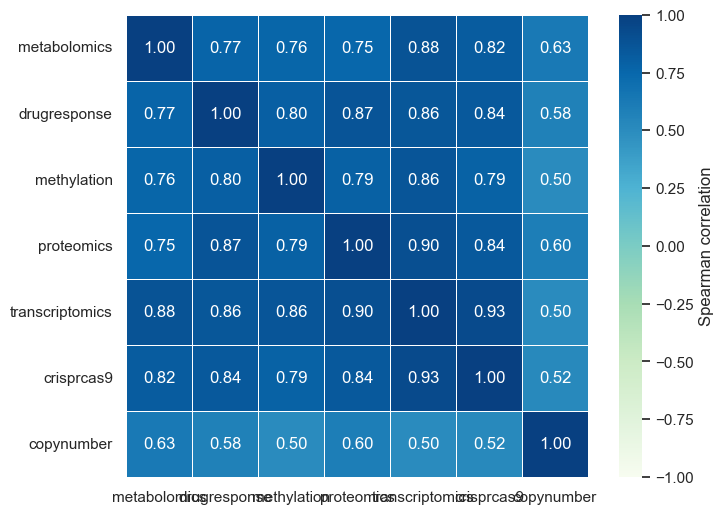

In [19]:
r_pearson, p_pearson = op.corr_matrix(by_obs[cfg.OMICS], "pearson")
r_spearman, p_spearman = op.corr_matrix(by_obs[cfg.OMICS], "spearman")
display(r_pearson, p_pearson, r_spearman, p_spearman)
op.plot_corr_heatmap(r_spearman, cbar_label="Spearman correlation", fontsize=11)
plt.show()

Observations with exactly one omic: 45


metabolomics       38
copynumber          7
drugresponse        0
methylation         0
proteomics          0
transcriptomics     0
crisprcas9          0
Name: n observations, dtype: int64

drugresponse, n_omics = 2: only 7 observations, skipped
methylation, n_omics = 2: only 9 observations, skipped
methylation, n_omics = 3: only 11 observations, skipped
proteomics, n_omics = 2: only 1 observations, skipped
crisprcas9, n_omics = 2: only 18 observations, skipped
crisprcas9, n_omics = 3: only 24 observations, skipped


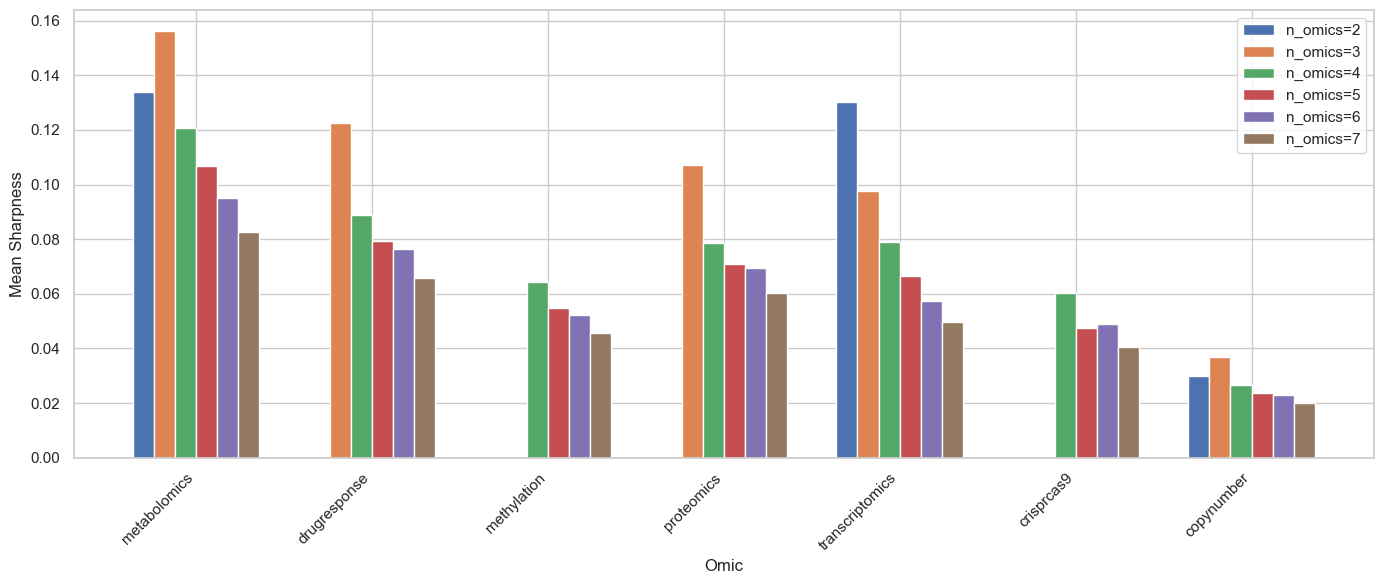

In [20]:
single = by_obs[by_obs["n_omics"] == 1]
print(f"Observations with exactly one omic: {len(single)}")
display(single[cfg.OMICS].notna().sum().sort_values(ascending=False).rename("n observations"))
op.plot_sharpness_by_n_omics(by_obs)

Quick checks.

In [21]:
print("Observations with both metabolomics and drug response:",
      (by_obs["metabolomics"].notna() & by_obs["drugresponse"].notna()).sum())
print("Observations without a known tissue:")
display(by_obs.loc[by_obs["tissue"] == "Unknown", "tissue"])
print("Samples labelled 'Eye':")
display(tissue[tissue == "Eye"])

Observations with both metabolomics and drug response: 634
Observations without a known tissue:


01658    Unknown
00597    Unknown
Name: tissue, dtype: object

Samples labelled 'Eye':


model_id
SIDM00075    Eye
SIDM00409    Eye
SIDM01395    Eye
SIDM01357    Eye
SIDM01414    Eye
SIDM01789    Eye
SIDM01793    Eye
SIDM01792    Eye
SIDM01843    Eye
SIDM01845    Eye
SIDM01844    Eye
Name: tissue, dtype: object

Mean sharpness per tissue, and a parallel-coordinates view of tissues with more than 20 observations.

,metabolomics,drugresponse,methylation,proteomics,transcriptomics,crisprcas9,copynumber,n_obs,continuous_mean_sharpness
tissue,,,,,,,,,
Eye,NaN,NaN,0.125655,NaN,NaN,NaN,0.046504,1,0.125655
Unknown,0.148899,NaN,0.078041,NaN,0.087797,0.079082,0.042263,2,0.098455
Small Intestine,NaN,0.117066,NaN,0.098498,0.078174,NaN,0.023229,1,0.097912
Biliary Tract,0.124284,0.096635,0.071450,0.085972,0.083318,0.060214,0.027285,13,0.086979
Peripheral Nervous System,0.115198,0.079236,0.059049,0.071101,0.070717,0.055638,0.023698,37,0.075156
Cervix,NaN,0.091824,0.065566,0.082359,0.077812,0.057764,0.028346,17,0.075065
Testis,NaN,0.087782,0.065887,0.081843,0.076444,0.062587,0.031058,3,0.074908
Vulva,NaN,0.095348,0.058505,0.087514,0.074006,0.052436,0.025655,3,0.073562
Soft Tissue,0.109211,0.081027,0.055213,0.072991,0.068544,0.044307,0.023810,22,0.071882


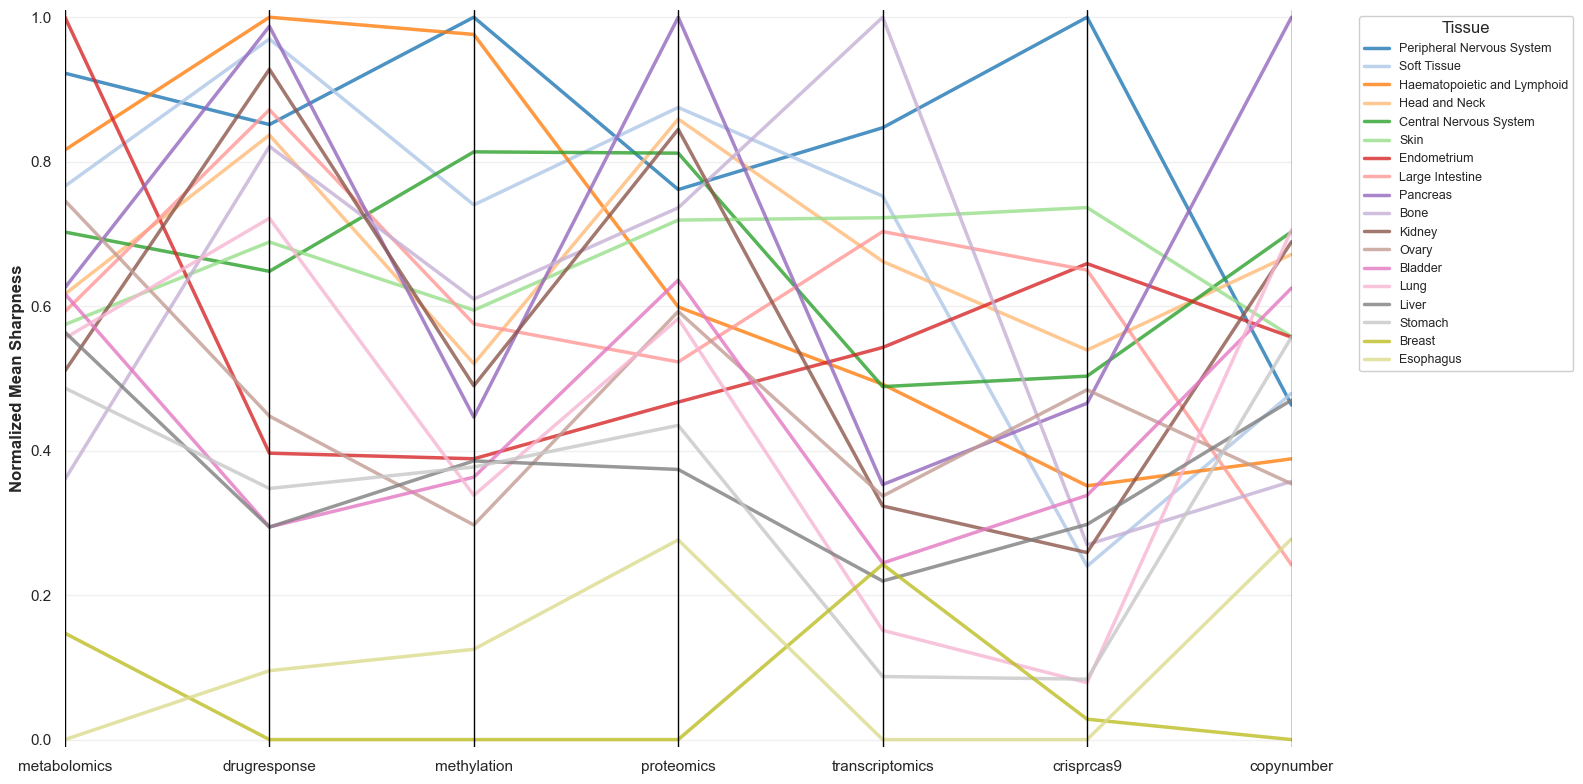

In [22]:
tissue_means = op.tissue_mean_sharpness(by_obs)
display(tissue_means)
op.plot_tissue_parallel(tissue_means)